#**SETUP**

In [6]:
!pip install geopandas pyogrio dbfread
!pip install geopandas pyogrio dbfread simpledbf
!pip install rasterio matplotlib

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, f1_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from google.colab import drive
import os
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, confusion_matrix
from sklearn.metrics import accuracy_score, cohen_kappa_score
import scipy.stats as stats
import rasterio





In [8]:
# make screen wider, to fit all columns in one line

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

/tmp/ipykernel_11105/894104517.py:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipykernel_11105/894104517.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


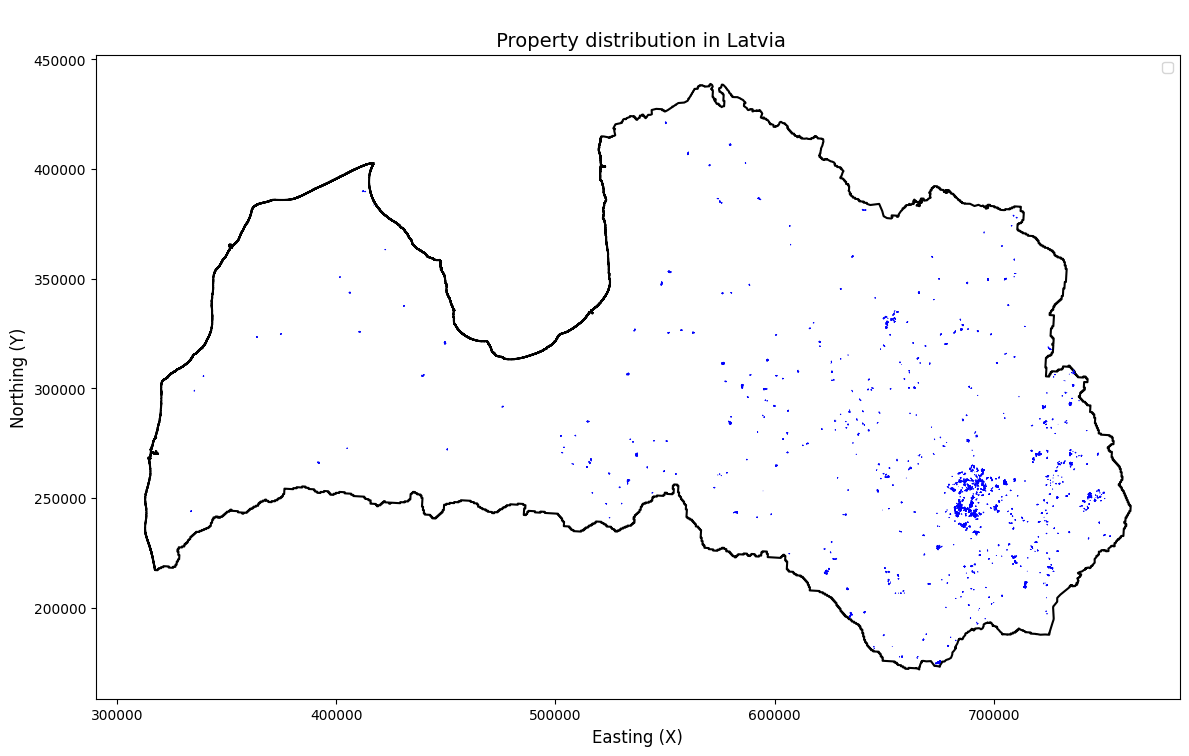

In [9]:
# Corrected path to shapefile
shape_file = "Nogapoly.shp"

# Show all rows
# Show all columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Load your Nogapoly shapefile
gdf = gpd.read_file("Nogapoly.shp")

# Load Latvia border from GADM
latvia = gpd.read_file("gadm41_LVA_0.shp")  # national border
latvia = latvia.to_crs(gdf.crs)
fig, ax = plt.subplots(figsize=(12, 12))

# Plot Latvia border
latvia.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.5, label="Latvia Border")
gdf.plot(ax=ax, edgecolor="blue", facecolor="lightblue", linewidth=0.5, label="Nogapoly Parcels")
ax.set_title("\n Property distribution in Latvia", fontsize=14)
ax.set_xlabel("Easting (X)", fontsize=12)
ax.set_ylabel("Northing (Y)", fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

#**DATA UPLOAD**



In [10]:
# data set loading
nfi_path = "/content/all_properties_coded.dbf"
sentinel_path = "/content/Latvia_NFI_S2_S1_Summer_2025_merged_coded.csv"

nfi_gdf = gpd.read_file(nfi_path)
nfi = pd.DataFrame(nfi_gdf)

sat = pd.read_csv(sentinel_path, sep=";")

print("NFI shape:", nfi.shape)
print("SAT shape:", sat.shape)
print("NFI columns sample:", list(nfi.columns)[:25])
print("SAT columns sample:", list(sat.columns)[:25])

NFI shape: (11497, 169)
SAT shape: (11497, 24)
NFI columns sample: ['APS', 'KAD', 'KV', 'NOG', 'ANOG', 'PLAT', 'EXPL_MEZS', 'EXPL_CELI', 'EXPL_GRAVJ', 'ZKAT', 'MT', 'BON', 'IZC', 'VGR', 'V_NOG', 'P_DARBV', 'P_DARBG', 'P_CIRP', 'P_CIRG', 'GK', 'PLANT', 'G1', 'K10', 'S10', 'A10']
SAT columns sample: ['system:index', 'APAKSNOG', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'KADNUM', 'KVARTALS', 'NBR', 'NDMI', 'NDRE', 'NDVI', 'NOGABALS', 'S1_VH', 'S1_VHdivVV', 'S1_VV', 'S1_VVminusVH', '.geo']


In [11]:
sat.head(5)


,system:index,APAKSNOG,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,KADNUM,KVARTALS,NBR,NDMI,NDRE,NDVI,NOGABALS,S1_VH,S1_VHdivVV,S1_VV,S1_VVminusVH,.geo
0,0000000000000000171f,0,0.138127,0.067726,0.034283,0.054576,0.031110,0.089005,0.221938,0.257896,0.270307,0.282285,100000000800,1,0.592612,0.315539,0.497899,0.791372,10,-14.508268,1.752536,-8.325867,6.182401,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1734,0,0.214008,0.108116,0.043449,0.071981,0.048361,0.121242,0.290209,0.336744,0.355309,0.366988,100000000801,1,0.534196,0.249423,0.490874,0.760974,10,-15.612470,1.638673,-9.637682,5.974788,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,1742,0,0.141804,0.070274,0.034709,0.054542,0.035416,0.086025,0.217944,0.256992,0.272394,0.281440,100000000803,1,0.586329,0.310739,0.515643,0.768743,10,-15.377103,1.555152,-9.957561,5.419542,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,0000000000000000175f,0,0.128629,0.058927,0.031824,0.048111,0.026933,0.074757,0.223016,0.271090,0.289142,0.295040,100000000799,1,0.661940,0.385019,0.588186,0.828854,10,-12.955367,1.991272,-6.669029,6.286338,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,0000000000000000176b,0,0.154700,0.074063,0.040208,0.059503,0.034928,0.093954,0.253066,0.292310,0.303696,0.316482,100000000806,1,0.609216,0.327172,0.526733,0.793557,10,-15.016307,1.660514,-9.106581,5.909726,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [12]:
#drop unnecessary columns in Sentinel dataset
df_sentinel = sat.drop(columns=[".geo", "system:index"], errors="ignore")
print(df_sentinel.shape)
print(df_sentinel.columns)

(11497, 22)
Index(['APAKSNOG', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'KADNUM', 'KVARTALS', 'NBR', 'NDMI', 'NDRE', 'NDVI', 'NOGABALS', 'S1_VH', 'S1_VHdivVV', 'S1_VV', 'S1_VVminusVH'], dtype='object')


In [13]:
df_nfi=nfi
df_nfi.head(5)

,APS,KAD,KV,NOG,ANOG,PLAT,EXPL_MEZS,EXPL_CELI,EXPL_GRAVJ,ZKAT,MT,BON,IZC,VGR,V_NOG,P_DARBV,P_DARBG,P_CIRP,P_CIRG,GK,PLANT,G1,K10,S10,A10,H10,D10,G10,N10,BV10,BA10,V10,B10,K11,S11,A11,H11,D11,G11,N11,BV11,BA11,V11,K12,S12,A12,H12,D12,G12,N12,BV12,BA12,V12,K13,S13,A13,H13,D13,G13,N13,BV13,BA13,V13,K14,S14,A14,H14,D14,G14,N14,BV14,BA14,V14,G2,K22,S22,A22,H22,D22,G22,N22,BV22,BA22,V22,B22,K23,S23,A23,H23,D23,G23,N23,BV23,BA23,V23,K24,S24,A24,H24,D24,G24,N24,BV24,BA24,V24,SSIZC,ATMIR,GTF,S51,A51,V51,S52,A52,V52,S53,A53,V53,SKOK1SUG,SKOK1SK,SKOK2SUG,SKOK2SK,SKOK3SUG,SKOK3SK,MRM_AV_NR,NEP_ATJ,MIN_SKER,APROB,MRM_PATS,MRM_SERT1,MRM_SERT2,MRM_SERT3,MRM_SERT4,MRM_SERT5,TKS_LIC_N,ATZARP,IEZP,NEP_JKOP,IPAT1,IPAT2,IPAT3,IPAT4,IPAT5,KOMP_KAD,KOMP_PLAT,MDZG,GTF_NATURE,GI,VA_KODS1,VA_KODS2,VA_KODS3,VA_KODS4,VA_KODS5,AIZS,VA_UNIK,AIZS_2,VA_UNIK_2,AIZS_3,VA_UNIK_3,AIZS_4,VA_UNIK_4,AIZS_5,VA_UNIK_5,INV_DATUMS,REG_DATUMS,INV_ATT,ORIG_ID,IZM_DATUMS,ATVK,LAST_UPDAT
0,xxxxxxxx,100000000113,1,10,0,0.03,0.03,0.0,0.0,10,5,0,1,2,305,0,0,0,0,0,0,26.0,10,4,44,26.0,25.0,26.0,0,0,0,305,8.52,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1982,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025
1,xxxxxxxx,100000000113,1,3,0,0.08,0.08,0.0,0.0,10,5,1,1,5,179,0,0,0,0,0,0,19.0,10,9,36,20.0,26.0,19.0,0,0,0,179,6.35,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1990,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025
2,xxxxxxxx,100000000113,1,8,0,0.05,0.05,0.0,0.0,10,5,1,1,4,289,1,2008,22,2008,0,0,24.0,7,4,79,28.0,32.0,17.0,0,0,0,209,7.59,3,4,59,26.0,24.0,7.0,0,0,0,80,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1947,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025
3,xxxxxxxx,100000000098,2,2,0,1.94,1.94,0.0,0.0,10,5,0,2,1,64,6,2007,0,0,2006,1,0.0,10,3,20,7.0,9.0,0.0,2560,0,0,64,8.00,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,03214301,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,2006,2001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,01.01.2001,0,0.0,09.03.2023,22560,15.04.2025
4,xxxxxxxx,100000000192,2,1,0,0.69,0.69,0.0,0.0,10,23,2,1,3,279,0,0,0,0,0,0,26.0,6,1,95,24.0,31.0,14.0,0,0,0,156,7.14,4,1,70,21.0,21.0,12.0,0,0,0,123,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1931,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,08.08.2006,0,0.0,None,31520,02.01.2025


In [14]:
print(df_sentinel.columns)
print(df_nfi.columns)

Index(['APAKSNOG', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'KADNUM', 'KVARTALS', 'NBR', 'NDMI', 'NDRE', 'NDVI', 'NOGABALS', 'S1_VH', 'S1_VHdivVV', 'S1_VV', 'S1_VVminusVH'], dtype='object')
Index(['APS', 'KAD', 'KV', 'NOG', 'ANOG', 'PLAT', 'EXPL_MEZS', 'EXPL_CELI', 'EXPL_GRAVJ', 'ZKAT',
       ...
       'VA_UNIK_4', 'AIZS_5', 'VA_UNIK_5', 'INV_DATUMS', 'REG_DATUMS', 'INV_ATT', 'ORIG_ID', 'IZM_DATUMS', 'ATVK', 'LAST_UPDAT'],
      dtype='object', length=169)


#**DATASET MERGING**

In [15]:
# Define key columns
sentinel_keys = ["KADNUM", "KVARTALS", "NOGABALS", "APAKSNOG"]
nfi_keys      = ["KAD", "KV", "NOG", "ANOG"]

# Convert to strings
for c in sentinel_keys:
    df_sentinel[c] = df_sentinel[c].astype("Int64").astype(str) if pd.api.types.is_numeric_dtype(df_sentinel[c]) else df_sentinel[c].astype(str)

for c in nfi_keys:
    # convert to Int64
    df_nfi[c] = df_nfi[c].astype("Int64").astype(str) if pd.api.types.is_numeric_dtype(df_nfi[c]) else df_nfi[c].astype(str)

# Build merge_id
df_sentinel["merge_id"] = df_sentinel[sentinel_keys].agg("_".join, axis=1)
df_nfi["merge_id"]      = df_nfi[nfi_keys].agg("_".join, axis=1)

# Merge
df_merged = df_nfi.merge(df_sentinel, on="merge_id", how="left")

print("Merged shape:", df_merged.shape)
print("Missing Sentinel rows:", df_merged.filter(regex="^B4$|^NDVI$").isna().any(axis=1).sum())
print(df_sentinel["merge_id"].head())
print(df_nfi["merge_id"].head())

Merged shape: (11497, 192)
Missing Sentinel rows: 0
0    100000000800_1_10_0
1    100000000801_1_10_0
2    100000000803_1_10_0
3    100000000799_1_10_0
4    100000000806_1_10_0
Name: merge_id, dtype: object
0    100000000113_1_10_0
1     100000000113_1_3_0
2     100000000113_1_8_0
3     100000000098_2_2_0
4     100000000192_2_1_0
Name: merge_id, dtype: object


#**DATA CONSISTENCY CHECKS**

In [16]:
# Number of duplicated merge_id rows
sentinel_dups = df_sentinel.duplicated("merge_id").sum()
print("Sentinel duplicate merge_id count:", sentinel_dups)

# See duplicated rows (if any)
df_sentinel[df_sentinel.duplicated("merge_id", keep=False)].head()

Sentinel duplicate merge_id count: 0


,APAKSNOG,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,KADNUM,KVARTALS,NBR,NDMI,NDRE,NDVI,NOGABALS,S1_VH,S1_VHdivVV,S1_VV,S1_VVminusVH,merge_id


In [17]:
nfi_dups = df_nfi.duplicated("merge_id").sum()
print("NFI duplicate merge_id count:", nfi_dups)

df_nfi[df_nfi.duplicated("merge_id", keep=False)].head()

NFI duplicate merge_id count: 0


,APS,KAD,KV,NOG,ANOG,PLAT,EXPL_MEZS,EXPL_CELI,EXPL_GRAVJ,ZKAT,MT,BON,IZC,VGR,V_NOG,P_DARBV,P_DARBG,P_CIRP,P_CIRG,GK,PLANT,G1,K10,S10,A10,H10,D10,G10,N10,BV10,BA10,V10,B10,K11,S11,A11,H11,D11,G11,N11,BV11,BA11,V11,K12,S12,A12,H12,D12,G12,N12,BV12,BA12,V12,K13,S13,A13,H13,D13,G13,N13,BV13,BA13,V13,K14,S14,A14,H14,D14,G14,N14,BV14,BA14,V14,G2,K22,S22,A22,H22,D22,G22,N22,BV22,BA22,V22,B22,K23,S23,A23,H23,D23,G23,N23,BV23,BA23,V23,K24,S24,A24,H24,D24,G24,N24,BV24,BA24,V24,SSIZC,ATMIR,GTF,S51,A51,V51,S52,A52,V52,S53,A53,V53,SKOK1SUG,SKOK1SK,SKOK2SUG,SKOK2SK,SKOK3SUG,SKOK3SK,MRM_AV_NR,NEP_ATJ,MIN_SKER,APROB,MRM_PATS,MRM_SERT1,MRM_SERT2,MRM_SERT3,MRM_SERT4,MRM_SERT5,TKS_LIC_N,ATZARP,IEZP,NEP_JKOP,IPAT1,IPAT2,IPAT3,IPAT4,IPAT5,KOMP_KAD,KOMP_PLAT,MDZG,GTF_NATURE,GI,VA_KODS1,VA_KODS2,VA_KODS3,VA_KODS4,VA_KODS5,AIZS,VA_UNIK,AIZS_2,VA_UNIK_2,AIZS_3,VA_UNIK_3,AIZS_4,VA_UNIK_4,AIZS_5,VA_UNIK_5,INV_DATUMS,REG_DATUMS,INV_ATT,ORIG_ID,IZM_DATUMS,ATVK,LAST_UPDAT,merge_id


In [18]:
df_merged.head(5)

,APS,KAD,KV,NOG,ANOG,PLAT,EXPL_MEZS,EXPL_CELI,EXPL_GRAVJ,ZKAT,MT,BON,IZC,VGR,V_NOG,P_DARBV,P_DARBG,P_CIRP,P_CIRG,GK,PLANT,G1,K10,S10,A10,H10,D10,G10,N10,BV10,BA10,V10,B10,K11,S11,A11,H11,D11,G11,N11,BV11,BA11,V11,K12,S12,A12,H12,D12,G12,N12,BV12,BA12,V12,K13,S13,A13,H13,D13,G13,N13,BV13,BA13,V13,K14,S14,A14,H14,D14,G14,N14,BV14,BA14,V14,G2,K22,S22,A22,H22,D22,G22,N22,BV22,BA22,V22,B22,K23,S23,A23,H23,D23,G23,N23,BV23,BA23,V23,K24,S24,A24,H24,D24,G24,N24,BV24,BA24,V24,SSIZC,ATMIR,GTF,S51,A51,V51,S52,A52,V52,S53,A53,V53,SKOK1SUG,SKOK1SK,SKOK2SUG,SKOK2SK,SKOK3SUG,SKOK3SK,MRM_AV_NR,NEP_ATJ,MIN_SKER,APROB,MRM_PATS,MRM_SERT1,MRM_SERT2,MRM_SERT3,MRM_SERT4,MRM_SERT5,TKS_LIC_N,ATZARP,IEZP,NEP_JKOP,IPAT1,IPAT2,IPAT3,IPAT4,IPAT5,KOMP_KAD,KOMP_PLAT,MDZG,GTF_NATURE,GI,VA_KODS1,VA_KODS2,VA_KODS3,VA_KODS4,VA_KODS5,AIZS,VA_UNIK,AIZS_2,VA_UNIK_2,AIZS_3,VA_UNIK_3,AIZS_4,VA_UNIK_4,AIZS_5,VA_UNIK_5,INV_DATUMS,REG_DATUMS,INV_ATT,ORIG_ID,IZM_DATUMS,ATVK,LAST_UPDAT,merge_id,APAKSNOG,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,KADNUM,KVARTALS,NBR,NDMI,NDRE,NDVI,NOGABALS,S1_VH,S1_VHdivVV,S1_VV,S1_VVminusVH
0,xxxxxxxx,100000000113,1,10,0,0.03,0.03,0.0,0.0,10,5,0,1,2,305,0,0,0,0,0,0,26.0,10,4,44,26.0,25.0,26.0,0,0,0,305,8.52,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1982,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_10_0,0,0.130331,0.058243,0.028117,0.044916,0.024608,0.075578,0.209284,0.241468,0.222977,0.257684,100000000113,1,0.582010,0.258367,0.490079,0.799335,10,-17.022829,1.538669,-11.072256,5.950573
1,xxxxxxxx,100000000113,1,3,0,0.08,0.08,0.0,0.0,10,5,1,1,5,179,0,0,0,0,0,0,19.0,10,9,36,20.0,26.0,19.0,0,0,0,179,6.35,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1990,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_3_0,0,0.174099,0.081770,0.034140,0.056322,0.029036,0.091141,0.279445,0.327332,0.348071,0.348151,100000000113,1,0.617135,0.329946,0.582784,0.844858,3,-14.889544,1.665088,-9.039722,5.849822
2,xxxxxxxx,100000000113,1,8,0,0.05,0.05,0.0,0.0,10,5,1,1,4,289,1,2008,22,2008,0,0,24.0,7,4,79,28.0,32.0,17.0,0,0,0,209,7.59,3,4,59,26.0,24.0,7.0,0,0,0,80,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1947,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_8_0,0,0.166761,0.076690,0.032798,0.054010,0.028337,0.092979,0.263717,0.311273,0.322582,0.336779,100000000113,1,0.613496,0.315815,0.550095,0.837378,8,-15.200837,1.638116,-9.307271,5.893566
3,xxxxxxxx,100000000098,2,2,0,1.94,1.94,0.0,0.0,10,5,0,2,1,64,6,2007,0,0,2006,1,0.0,10,3,20,7.0,9.0,0.0,2560,0,0,64,8.00,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,03214301,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,2006,2001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,01.01.2001,0,0.0,09.03.2023,22560,15.04.2025,100000000098_2_2_0,0,0.154787,0.073452,0.031682,0.051961,0.028651,0.088006,0.283818,0.344263,0.359352,0.370209,100000000098,2,0.657616,0.395208,0.602897,0.849504,2,-15.084313,1.744261,-8.810343,6.273971
4,xxxxxxxx,100000000192,2,1,0,0.69,0.69,0.0,0.0,10,23,2,1,3,279,0,0,0,0,0,0,26.0,6,1,95,24.0,31.0,14.0,0,0,0,156,7.14,4,1,70,21.0,21.0,12.0,0,0,0,123,0

In [19]:
df_merged.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
APS,11497,1,xxxxxxxx,11497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KAD,11497,1003,100000000664,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KV,11497,23,1,7010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOG,11497,100,1,1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANOG,11497,3,0,11446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PLAT,11497.0,NaN,NaN,NaN,0.970265,1.483056,0.0,0.27,0.55,1.11,35.09
EXPL_MEZS,11497.0,NaN,NaN,NaN,0.918691,1.458769,0.0,0.24,0.51,1.06,34.79
EXPL_CELI,11497.0,NaN,NaN,NaN,0.001103,0.009688,0.0,0.0,0.0,0.0,0.28
EXPL_GRAVJ,11497.0,NaN,NaN,NaN,0.00505,0.02379,0.0,0.0,0.0,0.0,1.06
ZKAT,11497.0,NaN,NaN,NaN,11.350352,5.156635,10.0,10.0,10.0,10.0,42.0


#**TARGET VARIABLE PREPARATION**

In [20]:
# Creating age class and adding it to dataframe. Classes: 1: 0–20, 2: 21–40, 3: 41–80, 4: ≥81

df_merged2 = df_merged.copy()

df_merged2["age_class"] = np.select(
    [
        df_merged2["A10"].between(0, 20, inclusive="both"),
        df_merged2["A10"].between(21, 40, inclusive="both"),
        df_merged2["A10"].between(41, 80, inclusive="both"),
        df_merged2["A10"] >= 81
    ],
    [1, 2, 3, 4],
    default=np.nan
)

print("Age class distribution:")
print(df_merged2["age_class"].value_counts(dropna=False).sort_index())


Age class distribution:
age_class
1.0    4801
2.0    2698
3.0    3315
4.0     683
Name: count, dtype: int64


In [21]:
df_merged2.head(5)

,APS,KAD,KV,NOG,ANOG,PLAT,EXPL_MEZS,EXPL_CELI,EXPL_GRAVJ,ZKAT,MT,BON,IZC,VGR,V_NOG,P_DARBV,P_DARBG,P_CIRP,P_CIRG,GK,PLANT,G1,K10,S10,A10,H10,D10,G10,N10,BV10,BA10,V10,B10,K11,S11,A11,H11,D11,G11,N11,BV11,BA11,V11,K12,S12,A12,H12,D12,G12,N12,BV12,BA12,V12,K13,S13,A13,H13,D13,G13,N13,BV13,BA13,V13,K14,S14,A14,H14,D14,G14,N14,BV14,BA14,V14,G2,K22,S22,A22,H22,D22,G22,N22,BV22,BA22,V22,B22,K23,S23,A23,H23,D23,G23,N23,BV23,BA23,V23,K24,S24,A24,H24,D24,G24,N24,BV24,BA24,V24,SSIZC,ATMIR,GTF,S51,A51,V51,S52,A52,V52,S53,A53,V53,SKOK1SUG,SKOK1SK,SKOK2SUG,SKOK2SK,SKOK3SUG,SKOK3SK,MRM_AV_NR,NEP_ATJ,MIN_SKER,APROB,MRM_PATS,MRM_SERT1,MRM_SERT2,MRM_SERT3,MRM_SERT4,MRM_SERT5,TKS_LIC_N,ATZARP,IEZP,NEP_JKOP,IPAT1,IPAT2,IPAT3,IPAT4,IPAT5,KOMP_KAD,KOMP_PLAT,MDZG,GTF_NATURE,GI,VA_KODS1,VA_KODS2,VA_KODS3,VA_KODS4,VA_KODS5,AIZS,VA_UNIK,AIZS_2,VA_UNIK_2,AIZS_3,VA_UNIK_3,AIZS_4,VA_UNIK_4,AIZS_5,VA_UNIK_5,INV_DATUMS,REG_DATUMS,INV_ATT,ORIG_ID,IZM_DATUMS,ATVK,LAST_UPDAT,merge_id,APAKSNOG,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,KADNUM,KVARTALS,NBR,NDMI,NDRE,NDVI,NOGABALS,S1_VH,S1_VHdivVV,S1_VV,S1_VVminusVH,age_class
0,xxxxxxxx,100000000113,1,10,0,0.03,0.03,0.0,0.0,10,5,0,1,2,305,0,0,0,0,0,0,26.0,10,4,44,26.0,25.0,26.0,0,0,0,305,8.52,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1982,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_10_0,0,0.130331,0.058243,0.028117,0.044916,0.024608,0.075578,0.209284,0.241468,0.222977,0.257684,100000000113,1,0.582010,0.258367,0.490079,0.799335,10,-17.022829,1.538669,-11.072256,5.950573,3.0
1,xxxxxxxx,100000000113,1,3,0,0.08,0.08,0.0,0.0,10,5,1,1,5,179,0,0,0,0,0,0,19.0,10,9,36,20.0,26.0,19.0,0,0,0,179,6.35,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1990,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_3_0,0,0.174099,0.081770,0.034140,0.056322,0.029036,0.091141,0.279445,0.327332,0.348071,0.348151,100000000113,1,0.617135,0.329946,0.582784,0.844858,3,-14.889544,1.665088,-9.039722,5.849822,2.0
2,xxxxxxxx,100000000113,1,8,0,0.05,0.05,0.0,0.0,10,5,1,1,4,289,1,2008,22,2008,0,0,24.0,7,4,79,28.0,32.0,17.0,0,0,0,209,7.59,3,4,59,26.0,24.0,7.0,0,0,0,80,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1947,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_8_0,0,0.166761,0.076690,0.032798,0.054010,0.028337,0.092979,0.263717,0.311273,0.322582,0.336779,100000000113,1,0.613496,0.315815,0.550095,0.837378,8,-15.200837,1.638116,-9.307271,5.893566,3.0
3,xxxxxxxx,100000000098,2,2,0,1.94,1.94,0.0,0.0,10,5,0,2,1,64,6,2007,0,0,2006,1,0.0,10,3,20,7.0,9.0,0.0,2560,0,0,64,8.00,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,03214301,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,2006,2001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,01.01.2001,0,0.0,09.03.2023,22560,15.04.2025,100000000098_2_2_0,0,0.154787,0.073452,0.031682,0.051961,0.028651,0.088006,0.283818,0.344263,0.359352,0.370209,100000000098,2,0.657616,0.395208,0.602897,0.849504,2,-15.084313,1.744261,-8.810343,6.273971,1.0
4,xxxxxxxx,100000000192,2,1,0,0.69,0.69,0.0,0.0,10,23,2,1,3,279,0,0,0,0,0,0,26.0,6,1,95,24.0,31.0,14.0,0,0,0,156,7.14,4,1,70,

In [22]:
df_merged3 = df_merged2.rename(columns={
    'V_NOG': 'GSV',
    'H10': 'HEIGHT',
    'S10': 'DOM_SPECIES'
})

In [23]:
df_merged3.head(5)

,APS,KAD,KV,NOG,ANOG,PLAT,EXPL_MEZS,EXPL_CELI,EXPL_GRAVJ,ZKAT,MT,BON,IZC,VGR,GSV,P_DARBV,P_DARBG,P_CIRP,P_CIRG,GK,PLANT,G1,K10,DOM_SPECIES,A10,HEIGHT,D10,G10,N10,BV10,BA10,V10,B10,K11,S11,A11,H11,D11,G11,N11,BV11,BA11,V11,K12,S12,A12,H12,D12,G12,N12,BV12,BA12,V12,K13,S13,A13,H13,D13,G13,N13,BV13,BA13,V13,K14,S14,A14,H14,D14,G14,N14,BV14,BA14,V14,G2,K22,S22,A22,H22,D22,G22,N22,BV22,BA22,V22,B22,K23,S23,A23,H23,D23,G23,N23,BV23,BA23,V23,K24,S24,A24,H24,D24,G24,N24,BV24,BA24,V24,SSIZC,ATMIR,GTF,S51,A51,V51,S52,A52,V52,S53,A53,V53,SKOK1SUG,SKOK1SK,SKOK2SUG,SKOK2SK,SKOK3SUG,SKOK3SK,MRM_AV_NR,NEP_ATJ,MIN_SKER,APROB,MRM_PATS,MRM_SERT1,MRM_SERT2,MRM_SERT3,MRM_SERT4,MRM_SERT5,TKS_LIC_N,ATZARP,IEZP,NEP_JKOP,IPAT1,IPAT2,IPAT3,IPAT4,IPAT5,KOMP_KAD,KOMP_PLAT,MDZG,GTF_NATURE,GI,VA_KODS1,VA_KODS2,VA_KODS3,VA_KODS4,VA_KODS5,AIZS,VA_UNIK,AIZS_2,VA_UNIK_2,AIZS_3,VA_UNIK_3,AIZS_4,VA_UNIK_4,AIZS_5,VA_UNIK_5,INV_DATUMS,REG_DATUMS,INV_ATT,ORIG_ID,IZM_DATUMS,ATVK,LAST_UPDAT,merge_id,APAKSNOG,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,KADNUM,KVARTALS,NBR,NDMI,NDRE,NDVI,NOGABALS,S1_VH,S1_VHdivVV,S1_VV,S1_VVminusVH,age_class
0,xxxxxxxx,100000000113,1,10,0,0.03,0.03,0.0,0.0,10,5,0,1,2,305,0,0,0,0,0,0,26.0,10,4,44,26.0,25.0,26.0,0,0,0,305,8.52,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1982,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_10_0,0,0.130331,0.058243,0.028117,0.044916,0.024608,0.075578,0.209284,0.241468,0.222977,0.257684,100000000113,1,0.582010,0.258367,0.490079,0.799335,10,-17.022829,1.538669,-11.072256,5.950573,3.0
1,xxxxxxxx,100000000113,1,3,0,0.08,0.08,0.0,0.0,10,5,1,1,5,179,0,0,0,0,0,0,19.0,10,9,36,20.0,26.0,19.0,0,0,0,179,6.35,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1990,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_3_0,0,0.174099,0.081770,0.034140,0.056322,0.029036,0.091141,0.279445,0.327332,0.348071,0.348151,100000000113,1,0.617135,0.329946,0.582784,0.844858,3,-14.889544,1.665088,-9.039722,5.849822,2.0
2,xxxxxxxx,100000000113,1,8,0,0.05,0.05,0.0,0.0,10,5,1,1,4,289,1,2008,22,2008,0,0,24.0,7,4,79,28.0,32.0,17.0,0,0,0,209,7.59,3,4,59,26.0,24.0,7.0,0,0,0,80,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1947,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_8_0,0,0.166761,0.076690,0.032798,0.054010,0.028337,0.092979,0.263717,0.311273,0.322582,0.336779,100000000113,1,0.613496,0.315815,0.550095,0.837378,8,-15.200837,1.638116,-9.307271,5.893566,3.0
3,xxxxxxxx,100000000098,2,2,0,1.94,1.94,0.0,0.0,10,5,0,2,1,64,6,2007,0,0,2006,1,0.0,10,3,20,7.0,9.0,0.0,2560,0,0,64,8.00,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,03214301,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,2006,2001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,01.01.2001,0,0.0,09.03.2023,22560,15.04.2025,100000000098_2_2_0,0,0.154787,0.073452,0.031682,0.051961,0.028651,0.088006,0.283818,0.344263,0.359352,0.370209,100000000098,2,0.657616,0.395208,0.602897,0.849504,2,-15.084313,1.744261,-8.810343,6.273971,1.0
4,xxxxxxxx,100000000192,2,1,0,0.69,0.69,0.0,0.0,10,23,2,1,3,279,0,0,0,0,0,0,26.0,6,1,95,24.0,31.0,14.0,0,0,0,156,7.1

In [24]:
target_cols = ['GSV', 'HEIGHT', 'DOM_SPECIES', 'age_class']
missing = df_merged3[target_cols].isna().sum()
missing

,0
GSV,0
HEIGHT,0
DOM_SPECIES,0
age_class,0


In [25]:
df_merged3[['GSV', 'HEIGHT', 'DOM_SPECIES', 'age_class']].dtypes

,0
GSV,int64
HEIGHT,float64
DOM_SPECIES,int64
age_class,float64


In [26]:
df = df_merged3.copy()
df['GSV'] = df_merged3['GSV'].astype(float)
df['HEIGHT'] = df_merged3['HEIGHT'].astype(float)
df['DOM_SPECIES'] = df_merged3['DOM_SPECIES'].astype(int)
df['age_class'] = df_merged3['age_class'].astype(int)

In [27]:
df.head(5)

,APS,KAD,KV,NOG,ANOG,PLAT,EXPL_MEZS,EXPL_CELI,EXPL_GRAVJ,ZKAT,MT,BON,IZC,VGR,GSV,P_DARBV,P_DARBG,P_CIRP,P_CIRG,GK,PLANT,G1,K10,DOM_SPECIES,A10,HEIGHT,D10,G10,N10,BV10,BA10,V10,B10,K11,S11,A11,H11,D11,G11,N11,BV11,BA11,V11,K12,S12,A12,H12,D12,G12,N12,BV12,BA12,V12,K13,S13,A13,H13,D13,G13,N13,BV13,BA13,V13,K14,S14,A14,H14,D14,G14,N14,BV14,BA14,V14,G2,K22,S22,A22,H22,D22,G22,N22,BV22,BA22,V22,B22,K23,S23,A23,H23,D23,G23,N23,BV23,BA23,V23,K24,S24,A24,H24,D24,G24,N24,BV24,BA24,V24,SSIZC,ATMIR,GTF,S51,A51,V51,S52,A52,V52,S53,A53,V53,SKOK1SUG,SKOK1SK,SKOK2SUG,SKOK2SK,SKOK3SUG,SKOK3SK,MRM_AV_NR,NEP_ATJ,MIN_SKER,APROB,MRM_PATS,MRM_SERT1,MRM_SERT2,MRM_SERT3,MRM_SERT4,MRM_SERT5,TKS_LIC_N,ATZARP,IEZP,NEP_JKOP,IPAT1,IPAT2,IPAT3,IPAT4,IPAT5,KOMP_KAD,KOMP_PLAT,MDZG,GTF_NATURE,GI,VA_KODS1,VA_KODS2,VA_KODS3,VA_KODS4,VA_KODS5,AIZS,VA_UNIK,AIZS_2,VA_UNIK_2,AIZS_3,VA_UNIK_3,AIZS_4,VA_UNIK_4,AIZS_5,VA_UNIK_5,INV_DATUMS,REG_DATUMS,INV_ATT,ORIG_ID,IZM_DATUMS,ATVK,LAST_UPDAT,merge_id,APAKSNOG,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,KADNUM,KVARTALS,NBR,NDMI,NDRE,NDVI,NOGABALS,S1_VH,S1_VHdivVV,S1_VV,S1_VVminusVH,age_class
0,xxxxxxxx,100000000113,1,10,0,0.03,0.03,0.0,0.0,10,5,0,1,2,305.0,0,0,0,0,0,0,26.0,10,4,44,26.0,25.0,26.0,0,0,0,305,8.52,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1982,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_10_0,0,0.130331,0.058243,0.028117,0.044916,0.024608,0.075578,0.209284,0.241468,0.222977,0.257684,100000000113,1,0.582010,0.258367,0.490079,0.799335,10,-17.022829,1.538669,-11.072256,5.950573,3
1,xxxxxxxx,100000000113,1,3,0,0.08,0.08,0.0,0.0,10,5,1,1,5,179.0,0,0,0,0,0,0,19.0,10,9,36,20.0,26.0,19.0,0,0,0,179,6.35,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1990,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_3_0,0,0.174099,0.081770,0.034140,0.056322,0.029036,0.091141,0.279445,0.327332,0.348071,0.348151,100000000113,1,0.617135,0.329946,0.582784,0.844858,3,-14.889544,1.665088,-9.039722,5.849822,2
2,xxxxxxxx,100000000113,1,8,0,0.05,0.05,0.0,0.0,10,5,1,1,4,289.0,1,2008,22,2008,0,0,24.0,7,4,79,28.0,32.0,17.0,0,0,0,209,7.59,3,4,59,26.0,24.0,7.0,0,0,0,80,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1947,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_8_0,0,0.166761,0.076690,0.032798,0.054010,0.028337,0.092979,0.263717,0.311273,0.322582,0.336779,100000000113,1,0.613496,0.315815,0.550095,0.837378,8,-15.200837,1.638116,-9.307271,5.893566,3
3,xxxxxxxx,100000000098,2,2,0,1.94,1.94,0.0,0.0,10,5,0,2,1,64.0,6,2007,0,0,2006,1,0.0,10,3,20,7.0,9.0,0.0,2560,0,0,64,8.00,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,03214301,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,2006,2001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,01.01.2001,0,0.0,09.03.2023,22560,15.04.2025,100000000098_2_2_0,0,0.154787,0.073452,0.031682,0.051961,0.028651,0.088006,0.283818,0.344263,0.359352,0.370209,100000000098,2,0.657616,0.395208,0.602897,0.849504,2,-15.084313,1.744261,-8.810343,6.273971,1
4,xxxxxxxx,100000000192,2,1,0,0.69,0.69,0.0,0.0,10,23,2,1,3,279.0,0,0,0,0,0,0,26.0,6,1,95,24.0,31.0,14.0,0,0,0,156,7

In [28]:
df[['GSV', 'HEIGHT', 'DOM_SPECIES', 'age_class']].dtypes

,0
GSV,float64
HEIGHT,float64
DOM_SPECIES,int64
age_class,int64


#**CORRELATION ANALYSIS**

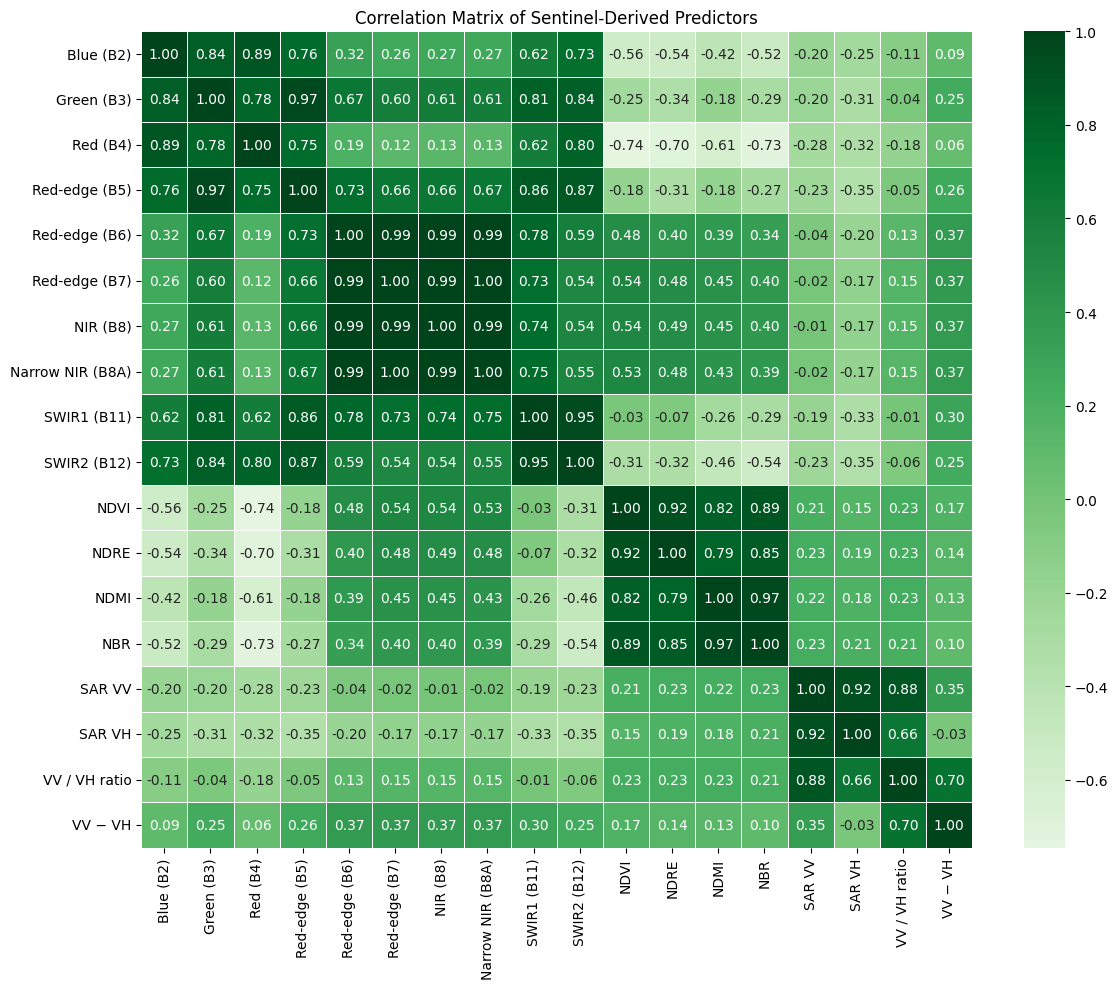

In [29]:
# All Sentinel derived features
predictor_cols_full = [
    "B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12",
    "NDVI","NDRE","NDMI","NBR",
    "S1_VV","S1_VH","S1_VHdivVV","S1_VVminusVH"
]

X = df[predictor_cols_full]

# User-friendly labels
predictor_labels = {
    "B2": "Blue (B2)",
    "B3": "Green (B3)",
    "B4": "Red (B4)",
    "B5": "Red-edge (B5)",
    "B6": "Red-edge (B6)",
    "B7": "Red-edge (B7)",
    "B8": "NIR (B8)",
    "B8A": "Narrow NIR (B8A)",
    "B11": "SWIR1 (B11)",
    "B12": "SWIR2 (B12)",
    "NDVI": "NDVI",
    "NDRE": "NDRE",
    "NDMI": "NDMI",
    "NBR": "NBR",
    "S1_VV": "SAR VV",
    "S1_VH": "SAR VH",
    "S1_VHdivVV": "VV / VH ratio",
    "S1_VVminusVH": "VV − VH"
}

# Rename columns for visualization only
X_plot = X.rename(columns=predictor_labels)

# Correlation matrix
corr = X_plot.corr(method="pearson")

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap="Greens",
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Sentinel-Derived Predictors")
plt.tight_layout()
plt.show()

In [30]:
# print predictor pairs with correlation =>0.90
threshold = 0.90
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = [
    (row, col, upper.loc[row, col])
    for row in upper.index
    for col in upper.columns
    if abs(upper.loc[row, col]) >= threshold
]

high_corr_pairs = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)
high_corr_pairs

[('Red-edge (B7)', 'Narrow NIR (B8A)', np.float64(0.998262371863695)),
 ('Red-edge (B7)', 'NIR (B8)', np.float64(0.9927888469893121)),
 ('Red-edge (B6)', 'Red-edge (B7)', np.float64(0.99232160033084)),
 ('NIR (B8)', 'Narrow NIR (B8A)', np.float64(0.991871418646852)),
 ('Red-edge (B6)', 'Narrow NIR (B8A)', np.float64(0.9902832875508556)),
 ('Red-edge (B6)', 'NIR (B8)', np.float64(0.9881599331643909)),
 ('NDMI', 'NBR', np.float64(0.9698211336492382)),
 ('Green (B3)', 'Red-edge (B5)', np.float64(0.9670706196097589)),
 ('SWIR1 (B11)', 'SWIR2 (B12)', np.float64(0.949042372250554)),
 ('SAR VV', 'SAR VH', np.float64(0.9248277724392243)),
 ('NDVI', 'NDRE', np.float64(0.9230173899796735))]

In [31]:
keep_priority = [
    # Sentinel-2 indices - interpretable, stable
    "NDVI", "NDMI", "NDRE",

    # Sentinel-2 structural bands
    "B4", "B6", "B11",  # red, red-edge, SWIR1

    # SAR (VH often reflects volume scattering)
    "S1_VH", "S1_VV", "S1_VHdivVV", "S1_VVminusVH"
]

keep_priority = [f for f in keep_priority if f in predictor_cols_full]
keep_priority


['NDVI',
 'NDMI',
 'NDRE',
 'B4',
 'B6',
 'B11',
 'S1_VH',
 'S1_VV',
 'S1_VHdivVV',
 'S1_VVminusVH']

#**FEATURE SELECTION BASED ON CORRELATION ANALYSIS**

In [32]:
# Full predictor list
predictor_cols_full = [
    "B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12",
    "NDVI","NDRE","NDMI","NBR",
    "S1_VV","S1_VH","S1_VHdivVV","S1_VVminusVH"
]

# Drop the collinear ones
to_drop = ["B5","B7","B8","B8A","B12","NDRE","NBR","S1_VH"]

predictor_cols_clean = [c for c in predictor_cols_full if c not in to_drop]

print("Dropped predictors:", to_drop)
print("\nPredictors kept:", len(predictor_cols_clean))
print(predictor_cols_clean)

Dropped predictors: ['B5', 'B7', 'B8', 'B8A', 'B12', 'NDRE', 'NBR', 'S1_VH']

Predictors kept: 10
['B2', 'B3', 'B4', 'B6', 'B11', 'NDVI', 'NDMI', 'S1_VV', 'S1_VHdivVV', 'S1_VVminusVH']


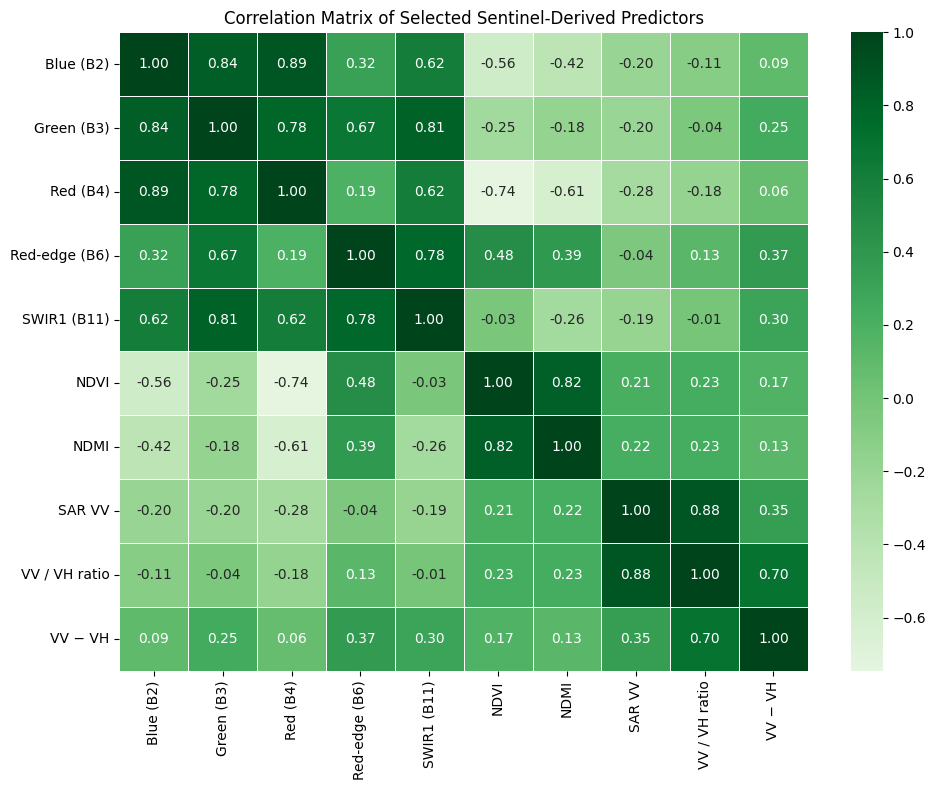

In [33]:
# Clean predictor dataset
X_clean = df[predictor_cols_clean]

# Rename columns only for visualization
X_plot = X_clean.rename(columns=predictor_labels)

# Correlation matrix
corr_clean = X_plot.corr(method="pearson")

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_clean,
    cmap="Greens",
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Selected Sentinel-Derived Predictors")
plt.tight_layout()
plt.show()

#**DESCRIPTIVE STATISTICS OF TARGET VARIABLES**

In [34]:
target_cols = ['GSV','HEIGHT','DOM_SPECIES','age_class']

target_summary = df_merged3[target_cols].describe().T
target_summary

,count,mean,std,min,25%,50%,75%,max
GSV,11497.0,136.289728,117.914659,0.0,23.0,127.0,218.0,887.0
HEIGHT,11497.0,12.956763,9.184323,0.0,4.0,14.0,21.0,34.0
DOM_SPECIES,11497.0,4.516830,3.417776,0.0,3.0,4.0,6.0,32.0
age_class,11497.0,1.989562,0.971351,1.0,1.0,2.0,3.0,4.0


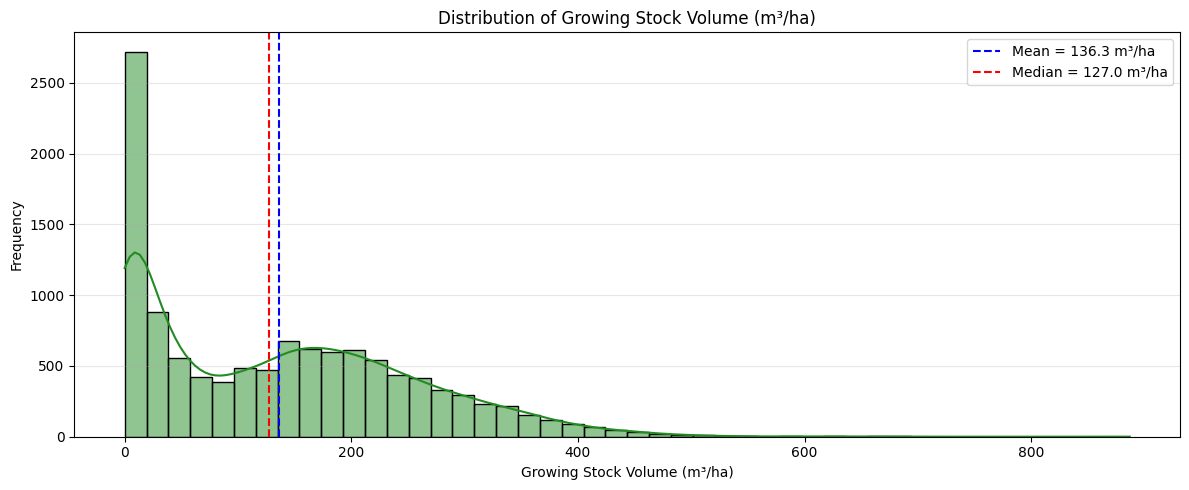

In [35]:
mean_gsv = df['GSV'].mean()
median_gsv = df['GSV'].median()

plt.figure(figsize=(12,5))

sns.histplot(df['GSV'], bins=46, color="forestgreen", edgecolor="black", kde=True)
plt.axvline(mean_gsv, color='blue', linestyle='--',label=f"Mean = {mean_gsv:.1f} m³/ha")

plt.axvline(median_gsv, color='red', linestyle='--',label=f"Median = {median_gsv:.1f} m³/ha")

plt.xlabel("Growing Stock Volume (m³/ha)")
plt.ylabel("Frequency")
plt.title("Distribution of Growing Stock Volume (m³/ha)")

plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

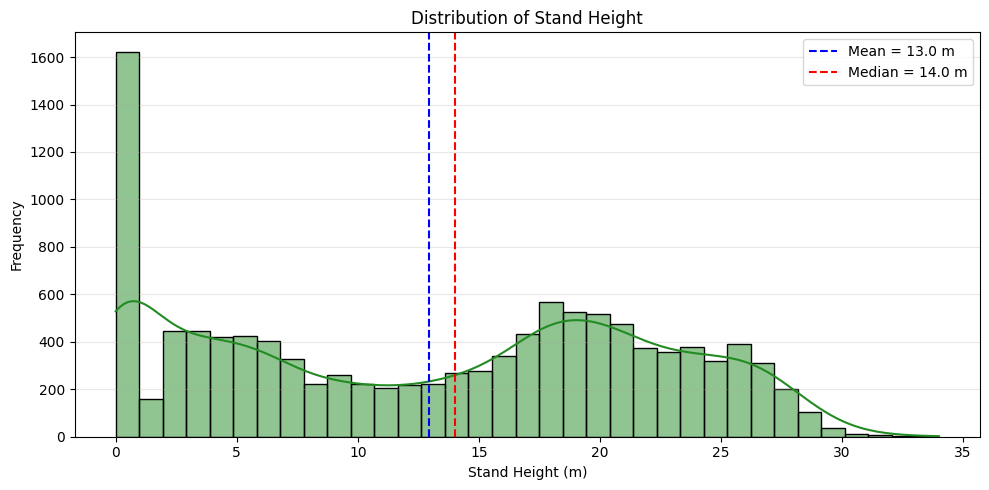

In [36]:
mean_height = df['HEIGHT'].mean()
median_height = df['HEIGHT'].median()

plt.figure(figsize=(10,5))

sns.histplot(df['HEIGHT'], bins=35,color="forestgreen",edgecolor="black",kde=True)

plt.axvline(mean_height, color='blue', linestyle='--',label=f"Mean = {mean_height:.1f} m")

plt.axvline(median_height, color='red', linestyle='--',label=f"Median = {median_height:.1f} m")

plt.xlabel("Stand Height (m)")
plt.ylabel("Frequency")
plt.title("Distribution of Stand Height")

plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

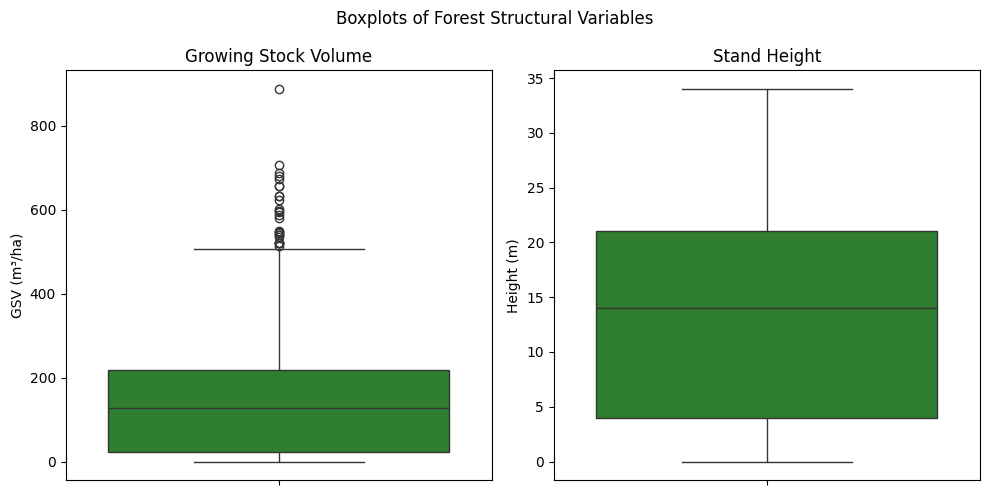

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

# GSV boxplot
sns.boxplot(y=df['GSV'], color="forestgreen", ax=ax[0])
ax[0].set_title("Growing Stock Volume")
ax[0].set_ylabel("GSV (m³/ha)")

# HEIGHT boxplot
sns.boxplot(y=df['HEIGHT'], color="forestgreen", ax=ax[1])
ax[1].set_title("Stand Height")
ax[1].set_ylabel("Height (m)")

plt.suptitle("Boxplots of Forest Structural Variables")

plt.tight_layout()
plt.show()

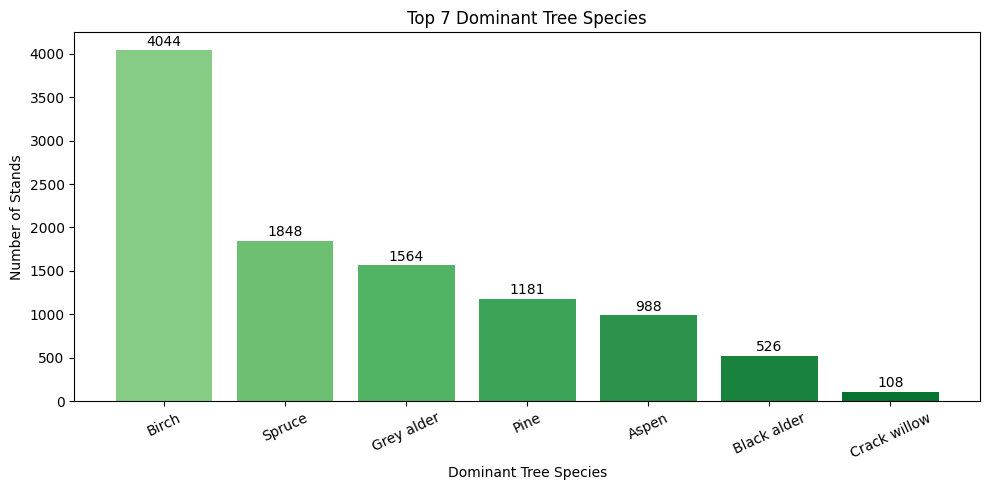

In [38]:
species_names = { 1:"Pine", 3:"Spruce", 4:"Birch", 6:"Black alder", 8:"Aspen", 9:"Grey alder", 10:"Oak", 11:"Ash", 12:"Linden",
                 13:"Larch", 14:"Other pines", 15:"Other spruces", 16:"Elm", 17:"European beech", 18:"Hornbeam", 19:"Poplar",
                 20:"Willow", 21:"Crack willow", 22:"Stone pine", 23:"Fir", 24:"Maple", 25:"Wild cherry", 26:"Wild apple",
                 27:"Pear", 28:"Douglas fir", 29:"Yew", 32:"Rowan", 35:"Bird cherry", 50:"Siberian peashrub", 61:"Other oaks",
                 62:"Other lindens", 63:"Other maples", 64:"Other ashes", 65:"Other elms", 66:"Walnut trees", 67:"Horse chestnut",
                 68:"Hybrid aspen", 69:"Black locust" }

# remove no-tree stands
species_counts = df[df['DOM_SPECIES'] != 0]['DOM_SPECIES'].value_counts().head(7)

# species names
labels = [species_names.get(i, "Unknown") for i in species_counts.index]

# green gradient
colors = plt.cm.Greens(np.linspace(0.45, 0.85, len(species_counts)))

plt.figure(figsize=(10,5))

bars = plt.bar(labels, species_counts.values, color=colors)

plt.xlabel("Dominant Tree Species")
plt.ylabel("Number of Stands")
plt.title("Top 7 Dominant Tree Species")

# value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50, f"{int(height)}",ha="center")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

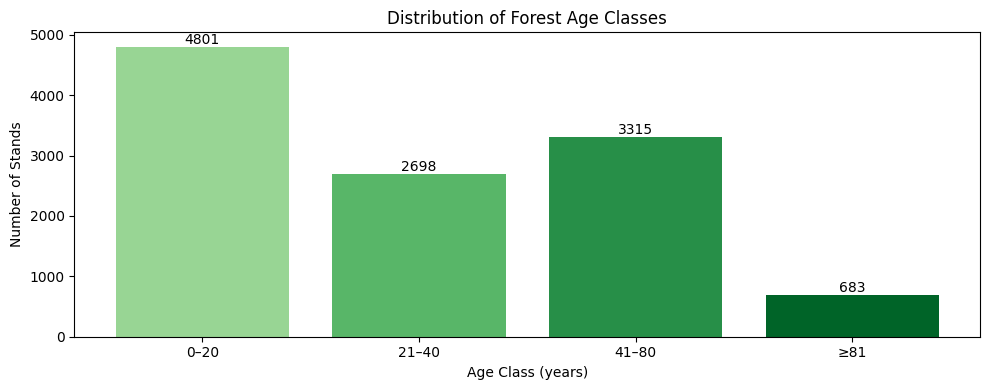

In [39]:
# count classes
age_counts = df_merged2["age_class"].value_counts().sort_index()

# labels
age_labels = ["0–20", "21–40", "41–80", "≥81"]

# green gradient colors
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(age_counts)))

plt.figure(figsize=(10,4))

bars = plt.bar(age_labels[:len(age_counts)], age_counts.values, color=colors)

plt.xlabel("Age Class (years)")
plt.ylabel("Number of Stands")
plt.title("Distribution of Forest Age Classes")

# add values above bars
for i, v in enumerate(age_counts.values):
    plt.text(i, v + 50, str(v), ha='center')

plt.tight_layout()
plt.show()

In [40]:
# Descriptive statistics for predictors
desc = df[predictor_cols_clean].describe().T

# Replace predictor codes with readable names
desc.index = desc.index.map(lambda x: predictor_labels.get(x, x))

# Round values for readability
desc = desc.round(3)

desc

,count,mean,std,min,25%,50%,75%,max
Blue (B2),11497.0,0.034,0.005,0.019,0.030,0.033,0.037,0.104
Green (B3),11497.0,0.056,0.009,0.032,0.049,0.054,0.061,0.141
Red (B4),11497.0,0.031,0.008,0.017,0.026,0.029,0.034,0.147
Red-edge (B6),11497.0,0.275,0.048,0.081,0.242,0.272,0.307,0.489
SWIR1 (B11),11497.0,0.166,0.028,0.057,0.147,0.164,0.183,0.307
NDVI,11497.0,0.830,0.046,0.403,0.813,0.839,0.859,0.917
NDMI,11497.0,0.345,0.057,-0.149,0.319,0.349,0.378,0.555
SAR VV,11497.0,-9.116,1.048,-15.736,-9.726,-9.023,-8.441,-4.799
VV / VH ratio,11497.0,1.701,0.108,1.364,1.632,1.695,1.760,2.513
VV − VH,11497.0,6.142,0.399,4.376,5.920,6.141,6.367,10.101


##**PREPARING DATAFRAMES FOR MODELLING TRASKS**

In [41]:
df.head(3)

,APS,KAD,KV,NOG,ANOG,PLAT,EXPL_MEZS,EXPL_CELI,EXPL_GRAVJ,ZKAT,MT,BON,IZC,VGR,GSV,P_DARBV,P_DARBG,P_CIRP,P_CIRG,GK,PLANT,G1,K10,DOM_SPECIES,A10,HEIGHT,D10,G10,N10,BV10,BA10,V10,B10,K11,S11,A11,H11,D11,G11,N11,BV11,BA11,V11,K12,S12,A12,H12,D12,G12,N12,BV12,BA12,V12,K13,S13,A13,H13,D13,G13,N13,BV13,BA13,V13,K14,S14,A14,H14,D14,G14,N14,BV14,BA14,V14,G2,K22,S22,A22,H22,D22,G22,N22,BV22,BA22,V22,B22,K23,S23,A23,H23,D23,G23,N23,BV23,BA23,V23,K24,S24,A24,H24,D24,G24,N24,BV24,BA24,V24,SSIZC,ATMIR,GTF,S51,A51,V51,S52,A52,V52,S53,A53,V53,SKOK1SUG,SKOK1SK,SKOK2SUG,SKOK2SK,SKOK3SUG,SKOK3SK,MRM_AV_NR,NEP_ATJ,MIN_SKER,APROB,MRM_PATS,MRM_SERT1,MRM_SERT2,MRM_SERT3,MRM_SERT4,MRM_SERT5,TKS_LIC_N,ATZARP,IEZP,NEP_JKOP,IPAT1,IPAT2,IPAT3,IPAT4,IPAT5,KOMP_KAD,KOMP_PLAT,MDZG,GTF_NATURE,GI,VA_KODS1,VA_KODS2,VA_KODS3,VA_KODS4,VA_KODS5,AIZS,VA_UNIK,AIZS_2,VA_UNIK_2,AIZS_3,VA_UNIK_3,AIZS_4,VA_UNIK_4,AIZS_5,VA_UNIK_5,INV_DATUMS,REG_DATUMS,INV_ATT,ORIG_ID,IZM_DATUMS,ATVK,LAST_UPDAT,merge_id,APAKSNOG,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,KADNUM,KVARTALS,NBR,NDMI,NDRE,NDVI,NOGABALS,S1_VH,S1_VHdivVV,S1_VV,S1_VVminusVH,age_class
0,xxxxxxxx,100000000113,1,10,0,0.03,0.03,0.0,0.0,10,5,0,1,2,305.0,0,0,0,0,0,0,26.0,10,4,44,26.0,25.0,26.0,0,0,0,305,8.52,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1982,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_10_0,0,0.130331,0.058243,0.028117,0.044916,0.024608,0.075578,0.209284,0.241468,0.222977,0.257684,100000000113,1,0.582010,0.258367,0.490079,0.799335,10,-17.022829,1.538669,-11.072256,5.950573,3
1,xxxxxxxx,100000000113,1,3,0,0.08,0.08,0.0,0.0,10,5,1,1,5,179.0,0,0,0,0,0,0,19.0,10,9,36,20.0,26.0,19.0,0,0,0,179,6.35,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1990,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_3_0,0,0.174099,0.081770,0.034140,0.056322,0.029036,0.091141,0.279445,0.327332,0.348071,0.348151,100000000113,1,0.617135,0.329946,0.582784,0.844858,3,-14.889544,1.665088,-9.039722,5.849822,2
2,xxxxxxxx,100000000113,1,8,0,0.05,0.05,0.0,0.0,10,5,1,1,4,289.0,1,2008,22,2008,0,0,24.0,7,4,79,28.0,32.0,17.0,0,0,0,209,7.59,3,4,59,26.0,24.0,7.0,0,0,0,80,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1947,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_8_0,0,0.166761,0.076690,0.032798,0.054010,0.028337,0.092979,0.263717,0.311273,0.322582,0.336779,100000000113,1,0.613496,0.315815,0.550095,0.837378,8,-15.200837,1.638116,-9.307271,5.893566,3


In [42]:
# creating 4 dataframes, for each prediction
df_reg_volume_full = df[["merge_id"] + predictor_cols_clean + ["GSV"]].copy()
df_reg_height_full = df[["merge_id"] + predictor_cols_clean + ["HEIGHT"]].copy()
df_clf_species_full = df[["merge_id"] + predictor_cols_clean + ["DOM_SPECIES"]].copy()
df_clf_ageclass_full = df[["merge_id"] + predictor_cols_clean + ["age_class"]].copy()

In [43]:
df_reg_volume_full.head(1)

,merge_id,B2,B3,B4,B6,B11,NDVI,NDMI,S1_VV,S1_VHdivVV,S1_VVminusVH,GSV
0,100000000113_1_10_0,0.028117,0.044916,0.024608,0.209284,0.130331,0.799335,0.258367,-11.072256,1.538669,5.950573,305.0


In [44]:
df_reg_volume_full.head(1)

,merge_id,B2,B3,B4,B6,B11,NDVI,NDMI,S1_VV,S1_VHdivVV,S1_VVminusVH,GSV
0,100000000113_1_10_0,0.028117,0.044916,0.024608,0.209284,0.130331,0.799335,0.258367,-11.072256,1.538669,5.950573,305.0


In [45]:
df_reg_volume_full.head(1)

,merge_id,B2,B3,B4,B6,B11,NDVI,NDMI,S1_VV,S1_VHdivVV,S1_VVminusVH,GSV
0,100000000113_1_10_0,0.028117,0.044916,0.024608,0.209284,0.130331,0.799335,0.258367,-11.072256,1.538669,5.950573,305.0


In [46]:
df_clf_species_full.head(1)

,merge_id,B2,B3,B4,B6,B11,NDVI,NDMI,S1_VV,S1_VHdivVV,S1_VVminusVH,DOM_SPECIES
0,100000000113_1_10_0,0.028117,0.044916,0.024608,0.209284,0.130331,0.799335,0.258367,-11.072256,1.538669,5.950573,4


In [47]:
df_clf_ageclass_full.head(1)

,merge_id,B2,B3,B4,B6,B11,NDVI,NDMI,S1_VV,S1_VHdivVV,S1_VVminusVH,age_class
0,100000000113_1_10_0,0.028117,0.044916,0.024608,0.209284,0.130331,0.799335,0.258367,-11.072256,1.538669,5.950573,3


In [48]:
# creating 4 dataframes, for each prediction
df_reg_volume_model = df_reg_volume_full[predictor_cols_clean + ["GSV"]].dropna(subset=["GSV"])
df_reg_height_model = df_reg_height_full[predictor_cols_clean + ["HEIGHT"]].dropna(subset=["HEIGHT"])
df_clf_species_model = df_clf_species_full[predictor_cols_clean + ["DOM_SPECIES"]].dropna(subset=["DOM_SPECIES"])
df_clf_ageclass_model = df_clf_ageclass_full[predictor_cols_clean + ["age_class"]].dropna(subset=["age_class"])

In [49]:
df_reg_volume_model.head(3)

,B2,B3,B4,B6,B11,NDVI,NDMI,S1_VV,S1_VHdivVV,S1_VVminusVH,GSV
0,0.028117,0.044916,0.024608,0.209284,0.130331,0.799335,0.258367,-11.072256,1.538669,5.950573,305.0
1,0.034140,0.056322,0.029036,0.279445,0.174099,0.844858,0.329946,-9.039722,1.665088,5.849822,179.0
2,0.032798,0.054010,0.028337,0.263717,0.166761,0.837378,0.315815,-9.307271,1.638116,5.893566,289.0


In [50]:
df_reg_height_model.head(3)

,B2,B3,B4,B6,B11,NDVI,NDMI,S1_VV,S1_VHdivVV,S1_VVminusVH,HEIGHT
0,0.028117,0.044916,0.024608,0.209284,0.130331,0.799335,0.258367,-11.072256,1.538669,5.950573,26.0
1,0.034140,0.056322,0.029036,0.279445,0.174099,0.844858,0.329946,-9.039722,1.665088,5.849822,20.0
2,0.032798,0.054010,0.028337,0.263717,0.166761,0.837378,0.315815,-9.307271,1.638116,5.893566,28.0


In [51]:
df_clf_species_model.head(3)

,B2,B3,B4,B6,B11,NDVI,NDMI,S1_VV,S1_VHdivVV,S1_VVminusVH,DOM_SPECIES
0,0.028117,0.044916,0.024608,0.209284,0.130331,0.799335,0.258367,-11.072256,1.538669,5.950573,4
1,0.034140,0.056322,0.029036,0.279445,0.174099,0.844858,0.329946,-9.039722,1.665088,5.849822,9
2,0.032798,0.054010,0.028337,0.263717,0.166761,0.837378,0.315815,-9.307271,1.638116,5.893566,4


In [52]:
df_clf_ageclass_model.head(3)

,B2,B3,B4,B6,B11,NDVI,NDMI,S1_VV,S1_VHdivVV,S1_VVminusVH,age_class
0,0.028117,0.044916,0.024608,0.209284,0.130331,0.799335,0.258367,-11.072256,1.538669,5.950573,3
1,0.034140,0.056322,0.029036,0.279445,0.174099,0.844858,0.329946,-9.039722,1.665088,5.849822,2
2,0.032798,0.054010,0.028337,0.263717,0.166761,0.837378,0.315815,-9.307271,1.638116,5.893566,3


#**DATASET SPLITTING (Train 75% / Test 25%, random_state = 42)**

In [53]:
# Predictor matrix (same predictors for all models)
# predictor_cols_clean contains the selected Sentinel predictors
# (e.g., NDVI, NDMI, B4, B6, B11, SAR variables)

# Target variable: Growing Stock Volume
X_vol = df_reg_volume_model[predictor_cols_clean]
y_vol = df_reg_volume_model["GSV"]

# Target variable: Stand Height
X_h = df_reg_height_model[predictor_cols_clean]
y_h = df_reg_height_model["HEIGHT"]


# Target variable: Age Class
X_age = df_clf_ageclass_model[predictor_cols_clean]
y_age = df_clf_ageclass_model["age_class"]


# Target variable: Dominant Tree Species
X_sp = df_clf_species_model[predictor_cols_clean]
y_sp = df_clf_species_model["DOM_SPECIES"]

In [54]:
# DATASET SPLITTING (TRAIN / TEST)
# The dataset is split into:
# 75% training data – used to train the models
# 25% testing data – used for independent evaluation


# Growing Stock Volume (Regression)
X_train_vol, X_test_vol, y_train_vol, y_test_vol = train_test_split(
    X_vol,
    y_vol,
    test_size=0.25,     # 25% for testing
    random_state=42     # ensures reproducibility
)


# Stand Height (Regression)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h,
    y_h,
    test_size=0.25,
    random_state=42
)


# Age Class (Classification).Stratified sampling ensures that the proportion of age classes remains similar in both training and testing datasets
X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(
    X_age,
    y_age,
    test_size=0.25,
    random_state=42,
    stratify=y_age
)

# Dominant Tree Species (Classification). Stratified train–test split to preserve species distribution
# Count observations per species
species_counts = df["DOM_SPECIES"].value_counts()

# Keep species with at least 2 samples
valid_species = species_counts[species_counts > 1].index

# Filter dataset
df_clf_species_model = df[df["DOM_SPECIES"].isin(valid_species)].copy()

print("Original dataset:", df.shape)
print("Filtered dataset:", df_clf_species_model.shape)

# Predictors
X_sp = df_clf_species_model[predictor_cols_clean]

# Target variable
y_sp = df_clf_species_model["DOM_SPECIES"]



X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
    X_sp,
    y_sp,
    test_size=0.25,
    random_state=42,
    stratify=y_sp
)


print("GSV model - Train:", X_train_vol.shape, " Test:", X_test_vol.shape)
print("Height model - Train:", X_train_h.shape, " Test:", X_test_h.shape)
print("Age model - Train:", X_train_age.shape, " Test:", X_test_age.shape)
print("Species model - Train:", X_train_sp.shape, " Test:", X_test_sp.shape)

Original dataset: (11497, 193)
Filtered dataset: (11496, 193)
GSV model - Train: (8622, 10)  Test: (2875, 10)
Height model - Train: (8622, 10)  Test: (2875, 10)
Age model - Train: (8622, 10)  Test: (2875, 10)
Species model - Train: (8622, 10)  Test: (2874, 10)


##**REGRESSION: GSV PREDICTION by RF and GBR**

In [55]:
# RANDOM FOREST REGRESSION (Growing Stock Volume)

rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

# Train model
rf_pipeline.fit(X_train_vol, y_train_vol)

# Predictions
y_pred_rf = rf_pipeline.predict(X_test_vol)

# Evaluation metrics
rf_r2 = r2_score(y_test_vol, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test_vol, y_pred_rf))
rf_mae = mean_absolute_error(y_test_vol, y_pred_rf)
rf_bias = np.mean(y_pred_rf - y_test_vol)

print("Random Forest")
print(f"R²   : {rf_r2:.3f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"MAE  : {rf_mae:.2f}")
print(f"Bias : {rf_bias:.2f}")

Random Forest
R²   : 0.432
RMSE : 89.55
MAE  : 66.73
Bias : -0.91


In [56]:
# GRADIENT BOOSTING REGRESSION (Growing Stock Volume)
gbr_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train model
gbr_pipeline.fit(X_train_vol, y_train_vol)

# Predictions
y_pred_gbr = gbr_pipeline.predict(X_test_vol)

# Evaluation metrics
gbr_r2 = r2_score(y_test_vol, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test_vol, y_pred_gbr))
gbr_mae = mean_absolute_error(y_test_vol, y_pred_gbr)
gbr_bias = np.mean(y_pred_gbr - y_test_vol)

print("\nGradient Boosting")
print(f"R²   : {gbr_r2:.3f}")
print(f"RMSE : {gbr_rmse:.2f}")
print(f"MAE  : {gbr_mae:.2f}")
print(f"Bias : {gbr_bias:.2f}")


Gradient Boosting
R²   : 0.429
RMSE : 89.73
MAE  : 67.88
Bias : -1.54


In [57]:
results_volume = pd.DataFrame({
    "Model": ["RF_volume", "GBR_volume"],
    "R2": [rf_r2, gbr_r2],
    "RMSE": [rf_rmse, gbr_rmse],
    "MAE": [rf_mae, gbr_mae],
    "Bias": [rf_bias, gbr_bias],
}).round(3)

results_volume

,Model,R2,RMSE,MAE,Bias
0,RF_volume,0.432,89.552,66.732,-0.905
1,GBR_volume,0.429,89.734,67.882,-1.535


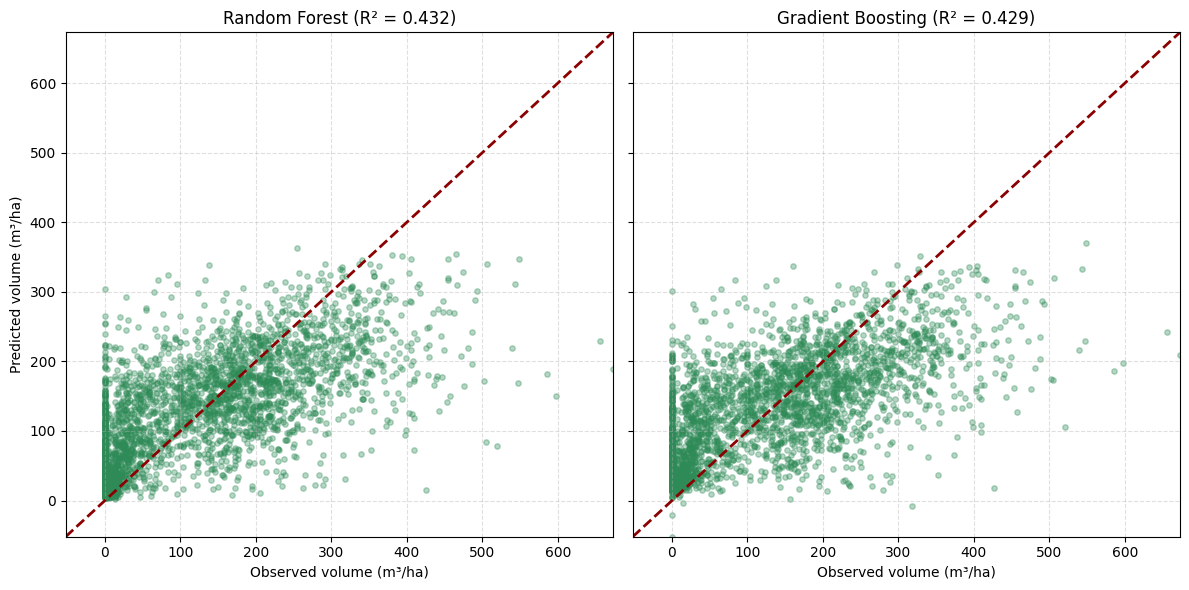

In [58]:
# Observed vs Predicted Scatterplots

fig, axes = plt.subplots(1, 2, figsize=(12,6), sharex=True, sharey=True)

# define colors
rf_color = "#2E8B57"   # forest green
gbr_color = "#2E8B57"  # darker green

# dynamic limits based on data
lims = [
    min(y_test_vol.min(), y_pred_rf.min(), y_pred_gbr.min()),
    max(y_test_vol.max(), y_pred_rf.max(), y_pred_gbr.max())
]

# Random Forest
axes[0].scatter(y_test_vol,y_pred_rf, alpha=0.35, s=15,color=rf_color)

axes[0].plot(lims, lims, linestyle="--", color="darkred", linewidth=2)

axes[0].set_title(f"Random Forest (R² = {rf_r2:.3f})")
axes[0].set_xlabel("Observed volume (m³/ha)")
axes[0].set_ylabel("Predicted volume (m³/ha)")

axes[0].grid(True, linestyle="--", alpha=0.4)


# Gradient Boosting
axes[1].scatter(y_test_vol,y_pred_gbr,alpha=0.35, s=15,color=gbr_color)

axes[1].plot(lims, lims, linestyle="--", color="darkred", linewidth=2)

axes[1].set_title(f"Gradient Boosting (R² = {gbr_r2:.3f})")
axes[1].set_xlabel("Observed volume (m³/ha)")

axes[1].grid(True, linestyle="--", alpha=0.4)


# apply same axis limits
for ax in axes:
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.show()

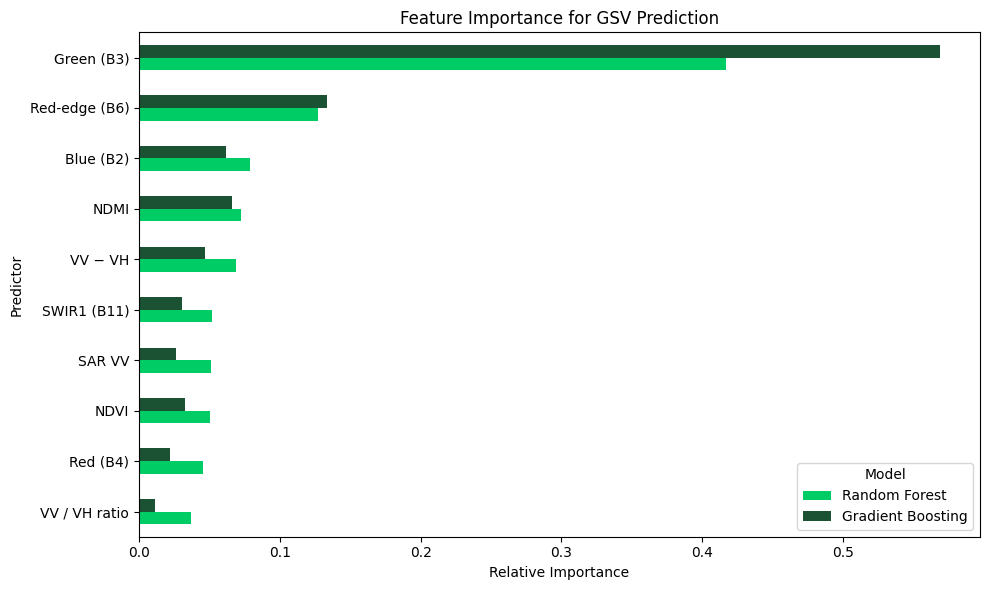

In [59]:
# User-friendly predictor names
predictor_labels = {
    "B2": "Blue (B2)",
    "B3": "Green (B3)",
    "B4": "Red (B4)",
    "B6": "Red-edge (B6)",
    "B11": "SWIR1 (B11)",
    "NDVI": "NDVI",
    "NDMI": "NDMI",
    "NDRE": "NDRE",
    "S1_VV": "SAR VV",
    "S1_VH": "SAR VH",
    "S1_VHdivVV": "VV / VH ratio",
    "S1_VVminusVH": "VV − VH"
}

# Combine feature importances
importance_df = pd.DataFrame({
    "Random Forest": rf_pipeline.named_steps["model"].feature_importances_,
    "Gradient Boosting": gbr_pipeline.named_steps["model"].feature_importances_
}, index=predictor_cols_clean)

# Sort predictors by Random Forest importance
importance_df = importance_df.sort_values(by="Random Forest")

# Replace predictor names with readable labels
importance_df.index = importance_df.index.map(lambda x: predictor_labels.get(x, x))

# Plot
importance_df.plot(
    kind="barh",
    figsize=(10,6),
    color=["#00cc66", "#1b5233"]
)

plt.xlabel("Relative Importance")
plt.ylabel("Predictor")
plt.title("Feature Importance for GSV Prediction")
plt.legend(title="Model")

plt.tight_layout()
plt.show()

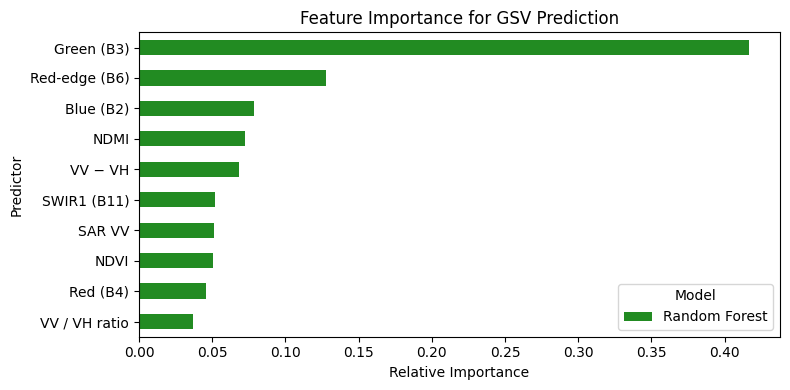

In [60]:
# User-friendly predictor names
predictor_labels = {
    "B2": "Blue (B2)",
    "B3": "Green (B3)",
    "B4": "Red (B4)",
    "B6": "Red-edge (B6)",
    "B11": "SWIR1 (B11)",
    "NDVI": "NDVI",
    "NDMI": "NDMI",
    "NDRE": "NDRE",
    "S1_VV": "SAR VV",
    "S1_VH": "SAR VH",
    "S1_VHdivVV": "VV / VH ratio",
    "S1_VVminusVH": "VV − VH"
}

# Combine feature importances
importance_df = pd.DataFrame({
    "Random Forest": rf_pipeline.named_steps["model"].feature_importances_,
}, index=predictor_cols_clean)

# Sort predictors by Random Forest importance
importance_df = importance_df.sort_values(by="Random Forest")

# Replace predictor names with readable labels
importance_df.index = importance_df.index.map(lambda x: predictor_labels.get(x, x))

# Plot
importance_df.plot(
    kind="barh",
    figsize=(8,4),
    color=["forestgreen"]
)

plt.xlabel("Relative Importance")
plt.ylabel("Predictor")
plt.title("Feature Importance for GSV Prediction")
plt.legend(title="Model")

plt.tight_layout()
plt.show()

In [61]:
gsv_corr = df_reg_volume_model[["GSV"] + predictor_cols_clean].corr()["GSV"].drop("GSV")
gsv_corr = gsv_corr.sort_values(key=abs, ascending=False)
gsv_corr

,GSV
B3,-0.525562
B6,-0.519514
B11,-0.475479
B2,-0.291698
B4,-0.276822
S1_VVminusVH,-0.245800
NDMI,-0.106489
NDVI,-0.092790
S1_VV,0.063142
S1_VHdivVV,-0.053133


##**REGRESSION: HEIGHT PREDICTION by RF and GBR**

In [62]:
# RANDOM FOREST – Stand Height

rf_height = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

# Train model
rf_height.fit(X_train_h, y_train_h)

# Predictions
y_pred_rf_h = rf_height.predict(X_test_h)

# Metrics
rf_h_r2 = r2_score(y_test_h, y_pred_rf_h)
rf_h_rmse = np.sqrt(mean_squared_error(y_test_h, y_pred_rf_h))
rf_h_mae = mean_absolute_error(y_test_h, y_pred_rf_h)
rf_h_bias = np.mean(y_pred_rf_h - y_test_h)

print("Random Forest – Height")
print(f"R²   : {rf_h_r2:.3f}")
print(f"RMSE : {rf_h_rmse:.2f}")
print(f"MAE  : {rf_h_mae:.2f}")
print(f"Bias : {rf_h_bias:.2f}")

Random Forest – Height
R²   : 0.453
RMSE : 6.81
MAE  : 5.31
Bias : -0.12


In [63]:
# GRADIENT BOOSTING – Stand Height

gbr_height = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train model
gbr_height.fit(X_train_h, y_train_h)

# Predictions
y_pred_gbr_h = gbr_height.predict(X_test_h)

# Metrics
gbr_h_r2 = r2_score(y_test_h, y_pred_gbr_h)
gbr_h_rmse = np.sqrt(mean_squared_error(y_test_h, y_pred_gbr_h))
gbr_h_mae = mean_absolute_error(y_test_h, y_pred_gbr_h)
gbr_h_bias = np.mean(y_pred_gbr_h - y_test_h)

print("Gradient Boosting – Height")
print(f"R²   : {gbr_h_r2:.3f}")
print(f"RMSE : {gbr_h_rmse:.2f}")
print(f"MAE  : {gbr_h_mae:.2f}")
print(f"Bias : {gbr_h_bias:.2f}")

Gradient Boosting – Height
R²   : 0.442
RMSE : 6.88
MAE  : 5.44
Bias : -0.09


In [64]:
results_height = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "R2": [rf_h_r2, gbr_h_r2],
    "RMSE": [rf_h_rmse, gbr_h_rmse],
    "MAE": [rf_h_mae, gbr_h_mae],
    "Bias": [rf_h_bias, gbr_h_bias]
}).round(3)

results_height

,Model,R2,RMSE,MAE,Bias
0,Random Forest,0.453,6.814,5.308,-0.117
1,Gradient Boosting,0.442,6.882,5.438,-0.093


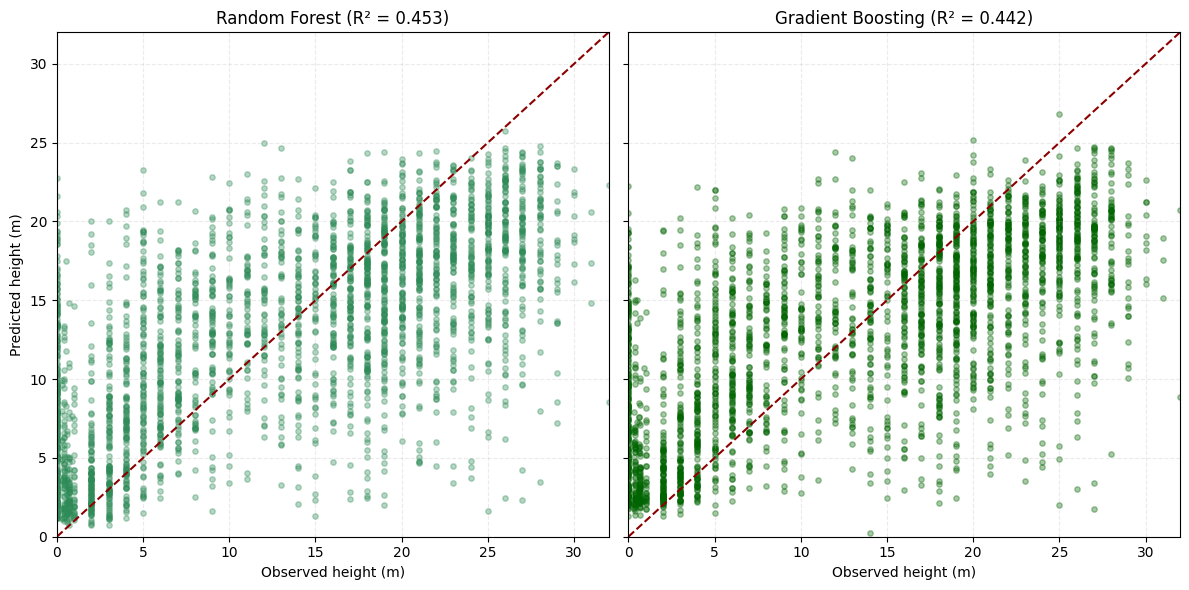

In [65]:
fig, axes = plt.subplots(1,2, figsize=(12,6), sharex=True, sharey=True)

lims = [0, max(y_test_h.max(), y_pred_rf_h.max(), y_pred_gbr_h.max())]

# RF
axes[0].scatter(y_test_h, y_pred_rf_h, alpha=0.35, s=15, color="#2E8B57")
axes[0].plot(lims, lims, "--", color="darkred")
axes[0].set_title(f"Random Forest (R² = {rf_h_r2:.3f})")
axes[0].set_xlabel("Observed height (m)")
axes[0].set_ylabel("Predicted height (m)")

# GBR
axes[1].scatter(y_test_h, y_pred_gbr_h, alpha=0.35, s=15, color="#006400")
axes[1].plot(lims, lims, "--", color="darkred")
axes[1].set_title(f"Gradient Boosting (R² = {gbr_h_r2:.3f})")
axes[1].set_xlabel("Observed height (m)")

for ax in axes:
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.grid(True, linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

In [66]:
# Random Forest importance
imp_rf_h = pd.Series(
    rf_height.named_steps["model"].feature_importances_,
    index=predictor_cols_clean
).sort_values()

# Gradient Boosting importance
imp_gbr_h = pd.Series(
    gbr_height.named_steps["model"].feature_importances_,
    index=predictor_cols_clean
).sort_values()

In [67]:
imp_height = pd.DataFrame({
    "Random Forest": imp_rf_h,
    "Gradient Boosting": imp_gbr_h
})

imp_height

,Random Forest,Gradient Boosting
B11,0.053330,0.048237
B2,0.078461,0.058636
B3,0.445825,0.599370
B4,0.042812,0.020866
B6,0.072290,0.062975
NDMI,0.098246,0.097813
NDVI,0.050768,0.030397
S1_VHdivVV,0.036323,0.008421
S1_VV,0.051801,0.026049
S1_VVminusVH,0.070145,0.047236


<Figure size 1000x600 with 0 Axes>

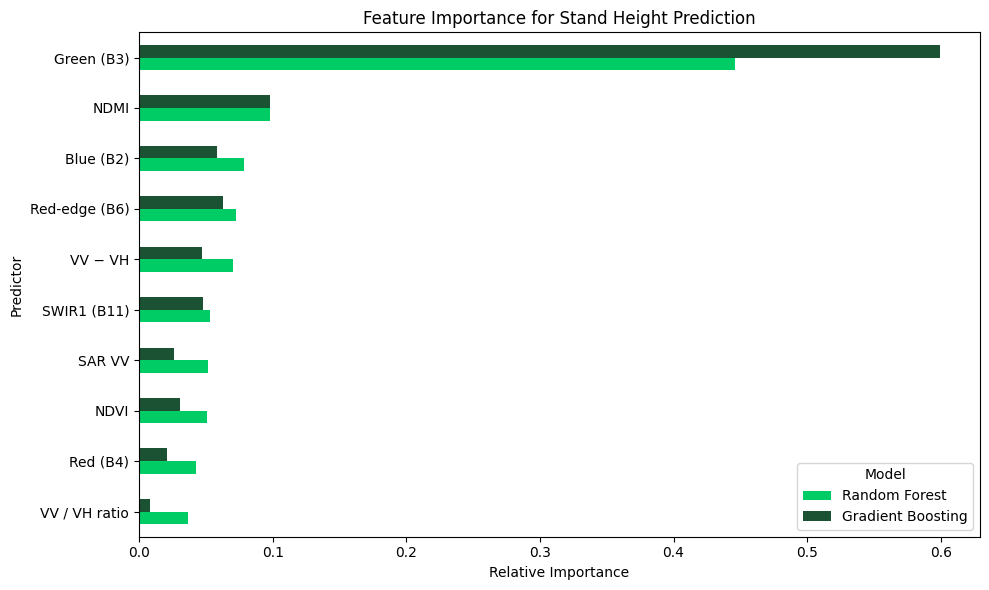

In [68]:
# User-friendly predictor labels
predictor_labels = {
    "B2": "Blue (B2)",
    "B3": "Green (B3)",
    "B4": "Red (B4)",
    "B6": "Red-edge (B6)",
    "B11": "SWIR1 (B11)",
    "NDVI": "NDVI",
    "NDMI": "NDMI",
    "NDRE": "NDRE",
    "S1_VV": "SAR VV",
    "S1_VH": "SAR VH",
    "S1_VHdivVV": "VV / VH ratio",
    "S1_VVminusVH": "VV − VH"
}

# Sort predictors by Random Forest importance
imp_height_sorted = imp_height.sort_values(by="Random Forest")

# Replace predictor names with readable labels
imp_height_sorted.index = imp_height_sorted.index.map(lambda x: predictor_labels.get(x, x))

# Plot
plt.figure(figsize=(10,6))

imp_height_sorted.plot(
    kind="barh",
    color=["#00cc66", "#1b5233"],
    figsize=(10,6)
)

plt.title("Feature Importance for Stand Height Prediction")
plt.xlabel("Relative Importance")
plt.ylabel("Predictor")
plt.legend(title="Model")

plt.tight_layout()
plt.show()

In [69]:
imp_height2 = pd.DataFrame({
    "Random Forest": imp_rf_h,
  })

imp_height2

,Random Forest
S1_VHdivVV,0.036323
B4,0.042812
NDVI,0.050768
S1_VV,0.051801
B11,0.053330
S1_VVminusVH,0.070145
B6,0.072290
B2,0.078461
NDMI,0.098246
B3,0.445825


<Figure size 800x400 with 0 Axes>

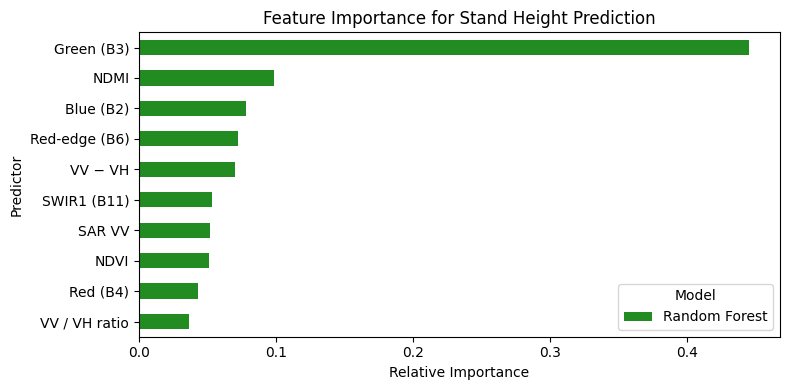

In [70]:

# Sort predictors by Random Forest importance
imp_height_sorted2 = imp_height2.sort_values(by="Random Forest")

# Replace predictor names with readable labels
imp_height_sorted2.index = imp_height_sorted.index.map(lambda x: predictor_labels.get(x, x))

# Plot
plt.figure(figsize=(8,4))

imp_height_sorted2.plot(
    kind="barh",
    color=["forestgreen"],
    figsize=(8,4)
)

plt.title("Feature Importance for Stand Height Prediction")
plt.xlabel("Relative Importance")
plt.ylabel("Predictor")
plt.legend(title="Model")

plt.tight_layout()
plt.show()

##**Classification: Age class prediction by RF and GBC**

In [71]:
# Random Forest classifier for age class
rf_age_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

# Train model
rf_age_pipeline.fit(X_train_age, y_train_age)

# Predict
y_pred_rf_age = rf_age_pipeline.predict(X_test_age)

In [72]:
# Gradient Boosting classifier for age class
gbr_age_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train model
gbr_age_pipeline.fit(X_train_age, y_train_age)

# Predict
y_pred_gbr_age = gbr_age_pipeline.predict(X_test_age)

In [73]:
# Random Forest metrics
rf_acc_age = accuracy_score(y_test_age, y_pred_rf_age)
rf_kappa_age = cohen_kappa_score(y_test_age, y_pred_rf_age)
rf_f1_age = f1_score(y_test_age, y_pred_rf_age, average="weighted")

# Gradient Boosting metrics
gbr_acc_age = accuracy_score(y_test_age, y_pred_gbr_age)
gbr_kappa_age = cohen_kappa_score(y_test_age, y_pred_gbr_age)
gbr_f1_age = f1_score(y_test_age, y_pred_gbr_age, average="weighted")

print("Random Forest Age Class")
print(f"Accuracy : {rf_acc_age:.3f}")
print(f"Kappa    : {rf_kappa_age:.3f}")
print(f"F1 score : {rf_f1_age:.3f}")

print("\nGradient Boosting Age Class")
print(f"Accuracy : {gbr_acc_age:.3f}")
print(f"Kappa    : {gbr_kappa_age:.3f}")
print(f"F1 score : {gbr_f1_age:.3f}")

Random Forest Age Class
Accuracy : 0.611
Kappa    : 0.416
F1 score : 0.594

Gradient Boosting Age Class
Accuracy : 0.601
Kappa    : 0.404
F1 score : 0.587


In [74]:
results_age = pd.DataFrame({
    "Model": ["RF_age_class", "GBR_age_class"],
    "Accuracy": [rf_acc_age, gbr_acc_age],
    "Kappa": [rf_kappa_age, gbr_kappa_age],
    "F1_score": [rf_f1_age, gbr_f1_age]
})

results_age

,Model,Accuracy,Kappa,F1_score
0,RF_age_class,0.611478,0.416444,0.594409
1,GBR_age_class,0.601391,0.404077,0.587339


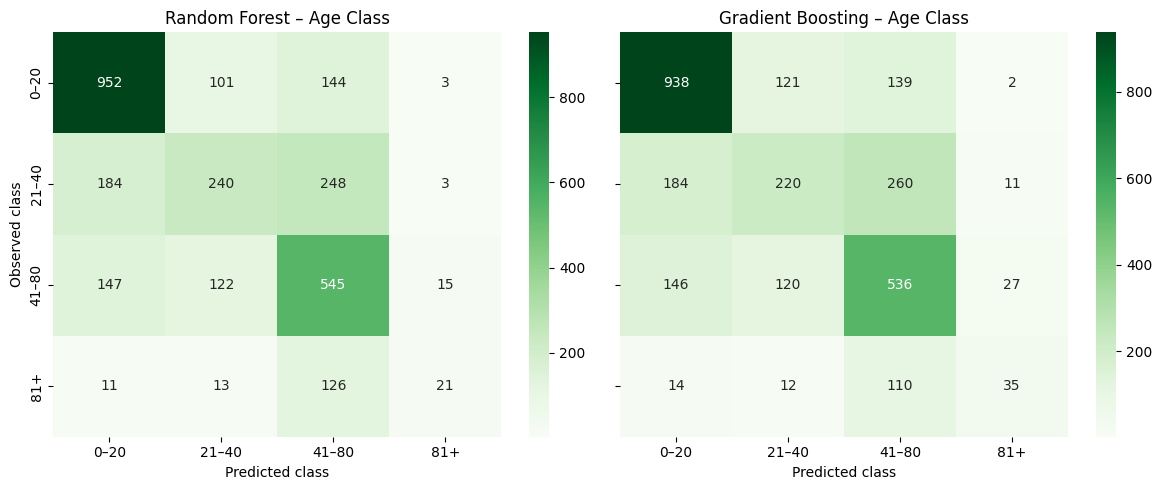

In [75]:
# Confusion matrices
cm_rf = confusion_matrix(y_test_age, y_pred_rf_age)
cm_gb = confusion_matrix(y_test_age, y_pred_gbr_age)

# Age class labels
age_labels = ["0–20", "21–40", "41–80", "81+"]

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# Random Forest
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=age_labels,
    yticklabels=age_labels,
    ax=axes[0]
)

axes[0].set_title("Random Forest – Age Class")
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("Observed class")

# Gradient Boosting
sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=age_labels,
    yticklabels=age_labels,
    ax=axes[1]
)

axes[1].set_title("Gradient Boosting – Age Class")
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [76]:
imp_age = pd.DataFrame({
    "Random Forest": rf_age_pipeline.named_steps["model"].feature_importances_,
    "Gradient Boosting": gbr_age_pipeline.named_steps["model"].feature_importances_
}, index=predictor_cols_clean)
imp_age.index = imp_age.index.map(lambda x: predictor_labels.get(x, x))
imp_age = imp_age.sort_values(by="Random Forest")

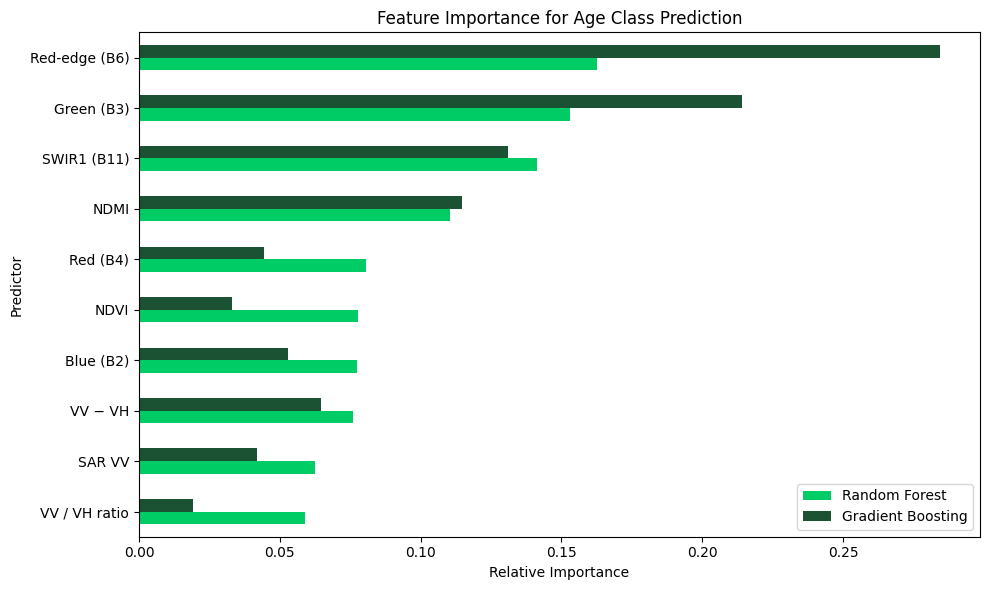

In [77]:
imp_age.plot(
    kind="barh",
    figsize=(10,6),
    color=["#00cc66","#1b5233"]
)

plt.title("Feature Importance for Age Class Prediction")
plt.xlabel("Relative Importance")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

In [78]:
imp_age2 = pd.DataFrame({
    "Random Forest": rf_age_pipeline.named_steps["model"].feature_importances_,
    }, index=predictor_cols_clean)
imp_age2.index = imp_age2.index.map(lambda x: predictor_labels.get(x, x))
imp_age2 = imp_age2.sort_values(by="Random Forest")

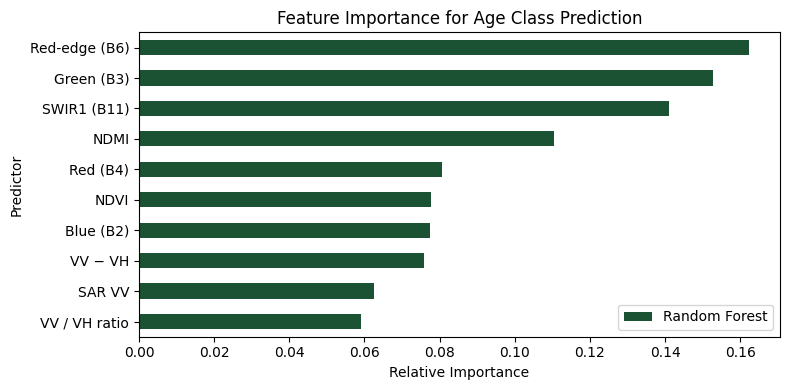

In [79]:
imp_age2.plot(
    kind="barh",
    figsize=(8,4),
    color=["#1b5233"]
)

plt.title("Feature Importance for Age Class Prediction")
plt.xlabel("Relative Importance")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

##**Classification: Dominant specie prediction**

In [80]:
# Random Forest classifier for dominant species
rf_species_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

# Train model
rf_species_pipeline.fit(X_train_sp, y_train_sp)

# Predict
y_pred_rf_sp = rf_species_pipeline.predict(X_test_sp)

In [81]:
# Gradient Boosting classifier for dominant species
gbr_species_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train
gbr_species_pipeline.fit(X_train_sp, y_train_sp)

# Predict
y_pred_gbr_sp = gbr_species_pipeline.predict(X_test_sp)

In [82]:
# Random Forest metrics
rf_acc_sp = accuracy_score(y_test_sp, y_pred_rf_sp)
rf_bal_acc_sp = balanced_accuracy_score(y_test_sp, y_pred_rf_sp)
rf_kappa_sp = cohen_kappa_score(y_test_sp, y_pred_rf_sp)
rf_f1_sp = f1_score(y_test_sp, y_pred_rf_sp, average="weighted")

# Gradient Boosting metrics
gbr_acc_sp = accuracy_score(y_test_sp, y_pred_gbr_sp)
gbr_bal_acc_sp = balanced_accuracy_score(y_test_sp, y_pred_gbr_sp)
gbr_kappa_sp = cohen_kappa_score(y_test_sp, y_pred_gbr_sp)
gbr_f1_sp = f1_score(y_test_sp, y_pred_gbr_sp, average="weighted")

In [83]:
results_species = pd.DataFrame({
    "Model": ["RF_species", "GBR_species"],
    "Accuracy": [rf_acc_sp, gbr_acc_sp],
    "Balanced_accuracy": [rf_bal_acc_sp, gbr_bal_acc_sp],
    "Kappa": [rf_kappa_sp, gbr_kappa_sp],
    "F1_score": [rf_f1_sp, gbr_f1_sp]
})

results_species


,Model,Accuracy,Balanced_accuracy,Kappa,F1_score
0,RF_species,0.517397,0.168511,0.356235,0.470516
1,GBR_species,0.505567,0.170222,0.347618,0.470832


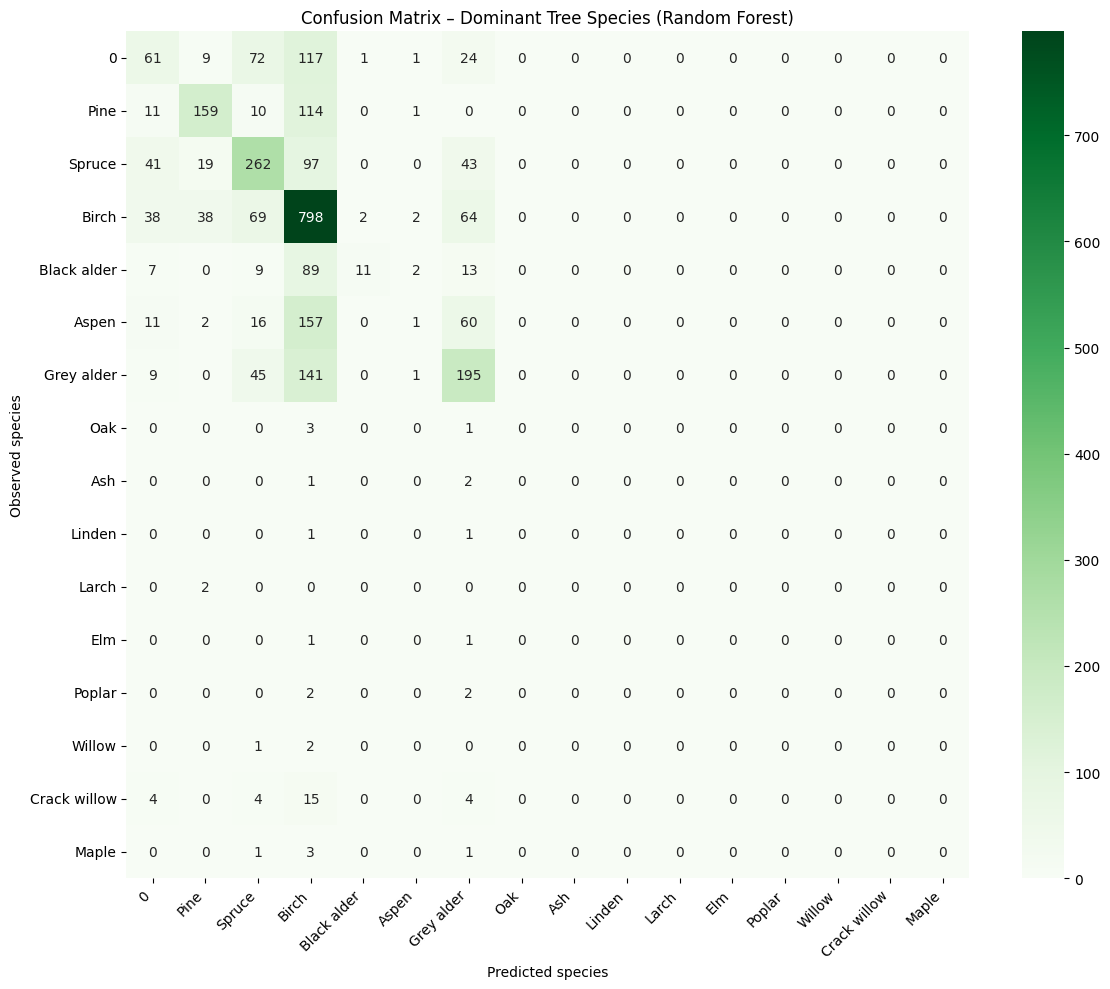

In [84]:
# Confusion matrix
cm_sp = confusion_matrix(y_test_sp, y_pred_rf_sp)

# Unique species codes present in test data
species_codes = sorted(np.unique(y_test_sp))

# Convert codes to names
species_labels = [species_names.get(code, str(code)) for code in species_codes]

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_sp,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=species_labels,
    yticklabels=species_labels
)

plt.xlabel("Predicted species")
plt.ylabel("Observed species")
plt.title("Confusion Matrix – Dominant Tree Species (Random Forest)")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [85]:
# Remove species code 0
species_counts = df[df["DOM_SPECIES"] != 0]["DOM_SPECIES"].value_counts()

# Top 7 species
top_species = species_counts.head(6).index.tolist()

print("Top species:", top_species)

Top species: [4, 3, 9, 1, 8, 6]


In [86]:
species_labels = [species_names.get(code, str(code)) for code in top_species]
mask = y_test_sp.isin(top_species)

y_test_top = y_test_sp[mask]
y_pred_rf_top = y_pred_rf_sp[mask]
y_pred_gbr_top = y_pred_gbr_sp[mask]
cm_rf = confusion_matrix(y_test_top, y_pred_rf_top, labels=top_species)
cm_gbr = confusion_matrix(y_test_top, y_pred_gbr_top, labels=top_species)

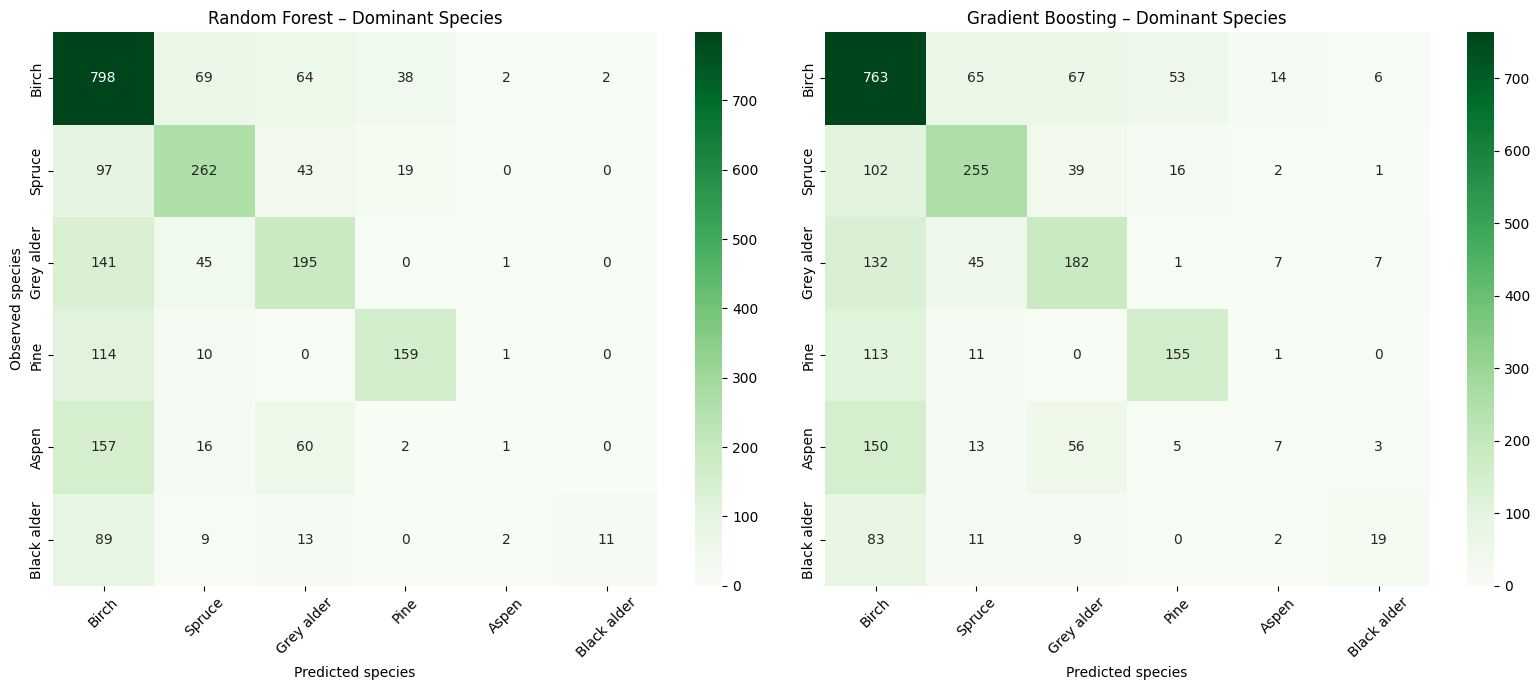

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16,7))

# Random Forest
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=species_labels,
    yticklabels=species_labels,
    ax=axes[0]
)

axes[0].set_title("Random Forest – Dominant Species")
axes[0].set_xlabel("Predicted species")
axes[0].set_ylabel("Observed species")
axes[0].tick_params(axis="x", rotation=45)

# Gradient Boosting
sns.heatmap(
    cm_gbr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=species_labels,
    yticklabels=species_labels,
    ax=axes[1]
)

axes[1].set_title("Gradient Boosting – Dominant Species")
axes[1].set_xlabel("Predicted species")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [88]:
imp_species = pd.DataFrame({
    "Random Forest": rf_species_pipeline.named_steps["model"].feature_importances_,
    "Gradient Boosting": gbr_species_pipeline.named_steps["model"].feature_importances_
}, index=predictor_cols_clean)
imp_species.index = imp_species.index.map(lambda x: predictor_labels.get(x, x))
imp_species = imp_species.sort_values(by="Random Forest")

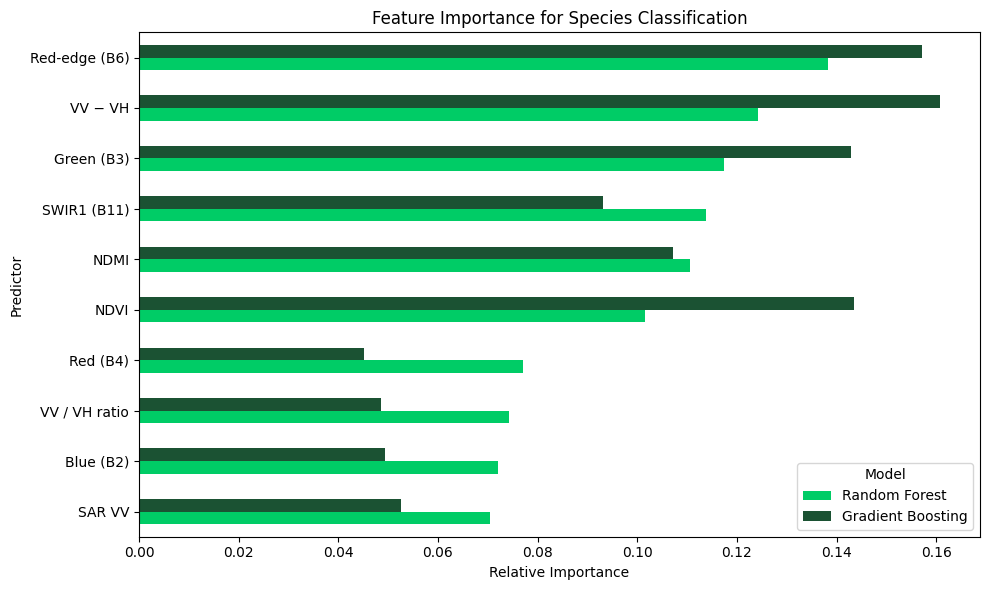

In [89]:
imp_species.plot(
    kind="barh",
    figsize=(10,6),
    color=["#00cc66", "#1b5233"]
)

plt.title("Feature Importance for Species Classification")
plt.xlabel("Relative Importance")
plt.ylabel("Predictor")
plt.legend(title="Model")

plt.tight_layout()
plt.show()

In [90]:
imp_species2 = pd.DataFrame({
    "Random Forest": rf_species_pipeline.named_steps["model"].feature_importances_,
    }, index=predictor_cols_clean)
imp_species2.index = imp_species2.index.map(lambda x: predictor_labels.get(x, x))
imp_species2 = imp_species2.sort_values(by="Random Forest")

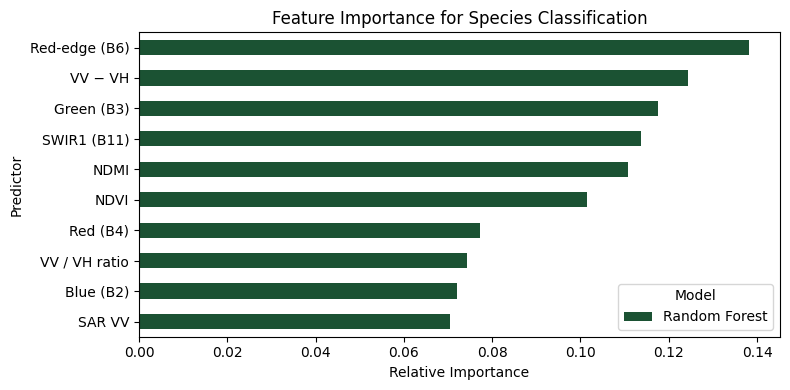

In [91]:
imp_species2.plot(
    kind="barh",
    figsize=(8,4),
    color=["#1b5233"]
)

plt.title("Feature Importance for Species Classification")
plt.xlabel("Relative Importance")
plt.ylabel("Predictor")
plt.legend(title="Model")

plt.tight_layout()
plt.show()

##**REGRESSION RESIDUAL DIAGNOSTIC**

In [92]:
df_pred = df.copy()

# predictions
df_pred["pred_height"] = rf_height.predict(df[X_train_h.columns])
df_pred["pred_volume"] = rf_pipeline.predict(df[X_train_vol.columns])

df_pred["pred_age_class"] = rf_age_pipeline.predict(df[X_train_age.columns])
df_pred["pred_species"] = rf_species_pipeline.predict(df[X_train_sp.columns])

# residuals
df_pred["gsv_residual"] = df_pred["GSV"] - df_pred["pred_volume"]
df_pred["height_residual"] = df_pred["HEIGHT"] - df_pred["pred_height"]

# absolute residual
df_pred["gsv_abs_error"] = np.abs(df_pred["gsv_residual"])
df_pred["height_abs_error"] = np.abs(df_pred["height_residual"])

# rounding
df_pred["height_residual"] = df_pred["height_residual"].round(1)
df_pred["gsv_residual"] = df_pred["gsv_residual"].round(1)

df_pred["height_abs_error"] = df_pred["height_abs_error"].round(1)
df_pred["gsv_abs_error"] = df_pred["gsv_abs_error"].round(1)

# classification correctness
df_pred["age_error"] = df_pred["age_class"] != df_pred["pred_age_class"]
df_pred["species_error"] = df_pred["DOM_SPECIES"] != df_pred["pred_species"]


# export
df_pred.to_csv("forest_predictions.csv", index=False)

In [93]:
df_pred.head(4)

,APS,KAD,KV,NOG,ANOG,PLAT,EXPL_MEZS,EXPL_CELI,EXPL_GRAVJ,ZKAT,MT,BON,IZC,VGR,GSV,P_DARBV,P_DARBG,P_CIRP,P_CIRG,GK,PLANT,G1,K10,DOM_SPECIES,A10,HEIGHT,D10,G10,N10,BV10,BA10,V10,B10,K11,S11,A11,H11,D11,G11,N11,BV11,BA11,V11,K12,S12,A12,H12,D12,G12,N12,BV12,BA12,V12,K13,S13,A13,H13,D13,G13,N13,BV13,BA13,V13,K14,S14,A14,H14,D14,G14,N14,BV14,BA14,V14,G2,K22,S22,A22,H22,D22,G22,N22,BV22,BA22,V22,B22,K23,S23,A23,H23,D23,G23,N23,BV23,BA23,V23,K24,S24,A24,H24,D24,G24,N24,BV24,BA24,V24,SSIZC,ATMIR,GTF,S51,A51,V51,S52,A52,V52,S53,A53,V53,SKOK1SUG,SKOK1SK,SKOK2SUG,SKOK2SK,SKOK3SUG,SKOK3SK,MRM_AV_NR,NEP_ATJ,MIN_SKER,APROB,MRM_PATS,MRM_SERT1,MRM_SERT2,MRM_SERT3,MRM_SERT4,MRM_SERT5,TKS_LIC_N,ATZARP,IEZP,NEP_JKOP,IPAT1,IPAT2,IPAT3,IPAT4,IPAT5,KOMP_KAD,KOMP_PLAT,MDZG,GTF_NATURE,GI,VA_KODS1,VA_KODS2,VA_KODS3,VA_KODS4,VA_KODS5,AIZS,VA_UNIK,AIZS_2,VA_UNIK_2,AIZS_3,VA_UNIK_3,AIZS_4,VA_UNIK_4,AIZS_5,VA_UNIK_5,INV_DATUMS,REG_DATUMS,INV_ATT,ORIG_ID,IZM_DATUMS,ATVK,LAST_UPDAT,merge_id,APAKSNOG,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,KADNUM,KVARTALS,NBR,NDMI,NDRE,NDVI,NOGABALS,S1_VH,S1_VHdivVV,S1_VV,S1_VVminusVH,age_class,pred_height,pred_volume,pred_age_class,pred_species,gsv_residual,height_residual,gsv_abs_error,height_abs_error,age_error,species_error
0,xxxxxxxx,100000000113,1,10,0,0.03,0.03,0.0,0.0,10,5,0,1,2,305.0,0,0,0,0,0,0,26.0,10,4,44,26.0,25.0,26.0,0,0,0,305,8.52,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1982,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_10_0,0,0.130331,0.058243,0.028117,0.044916,0.024608,0.075578,0.209284,0.241468,0.222977,0.257684,100000000113,1,0.582010,0.258367,0.490079,0.799335,10,-17.022829,1.538669,-11.072256,5.950573,3,19.049641,265.205377,3,4,39.8,7.0,39.8,7.0,False,False
1,xxxxxxxx,100000000113,1,3,0,0.08,0.08,0.0,0.0,10,5,1,1,5,179.0,0,0,0,0,0,0,19.0,10,9,36,20.0,26.0,19.0,0,0,0,179,6.35,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1990,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_3_0,0,0.174099,0.081770,0.034140,0.056322,0.029036,0.091141,0.279445,0.327332,0.348071,0.348151,100000000113,1,0.617135,0.329946,0.582784,0.844858,3,-14.889544,1.665088,-9.039722,5.849822,2,16.294971,139.101407,2,4,39.9,3.7,39.9,3.7,False,True
2,xxxxxxxx,100000000113,1,8,0,0.05,0.05,0.0,0.0,10,5,1,1,4,289.0,1,2008,22,2008,0,0,24.0,7,4,79,28.0,32.0,17.0,0,0,0,209,7.59,3,4,59,26.0,24.0,7.0,0,0,0,80,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,1947,2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,25.10.2006,0,0.0,24.08.2020,22510,02.01.2025,100000000113_1_8_0,0,0.166761,0.076690,0.032798,0.054010,0.028337,0.092979,0.263717,0.311273,0.322582,0.336779,100000000113,1,0.613496,0.315815,0.550095,0.837378,8,-15.200837,1.638116,-9.307271,5.893566,3,21.471082,202.502586,3,4,86.5,6.5,86.5,6.5,False,False
3,xxxxxxxx,100000000098,2,2,0,1.94,1.94,0.0,0.0,10,5,0,2,1,64.0,6,2007,0,0,2006,1,0.0,10,3,20,7.0,9.0,0.0,2560,0,0,64,8.00,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,03214301,0,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,None,6,None,None,None,0.0,0.0,0.0,None,0,0,0,0,0,0,0,0,0.0,0.0,2006,2001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,01.01.2001,0,0.0,09.03.2023,22560,15.04.2025,100000000098_2_2_0,0,

In [94]:
df_results = pd.DataFrame({
    "merge_id": df["merge_id"],
    "Forest type": df["ZKAT"],
    "PLAT": df["PLAT"],
    "GSV": df["GSV"],
    "DOM_SPECIES": df["DOM_SPECIES"],
    "HEIGHT": df["HEIGHT"],
    "GTF_NATURE": df["GTF_NATURE"],
    "age_class": df["age_class"],
    "pred_volume": df_pred["pred_volume"],
    "pred_height": df_pred["pred_height"],
    "pred_age_class": df_pred["pred_age_class"],
    "pred_species": df_pred["pred_species"],
    "gsv_residual": df_pred["gsv_residual"],
    "height_residual": df_pred["height_residual"],
    "gsv_abs_error": df_pred["gsv_abs_error"],
    "height_abs_error": df_pred["height_abs_error"],
    "age_error": df_pred["age_error"],
    "species_error": df_pred["species_error"]

})

In [95]:
df_results.head(5)

,merge_id,Forest type,PLAT,GSV,DOM_SPECIES,HEIGHT,GTF_NATURE,age_class,pred_volume,pred_height,pred_age_class,pred_species,gsv_residual,height_residual,gsv_abs_error,height_abs_error,age_error,species_error
0,100000000113_1_10_0,10,0.03,305.0,4,26.0,2006,3,265.205377,19.049641,3,4,39.8,7.0,39.8,7.0,False,False
1,100000000113_1_3_0,10,0.08,179.0,9,20.0,2006,2,139.101407,16.294971,2,4,39.9,3.7,39.9,3.7,False,True
2,100000000113_1_8_0,10,0.05,289.0,4,28.0,2006,3,202.502586,21.471082,3,4,86.5,6.5,86.5,6.5,False,False
3,100000000098_2_2_0,10,1.94,64.0,3,7.0,2001,1,172.508281,15.645935,1,3,-108.5,-8.6,108.5,8.6,False,False
4,100000000192_2_1_0,10,0.69,279.0,1,24.0,2006,4,240.474012,20.052267,4,1,38.5,3.9,38.5,3.9,False,False


In [96]:
df_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11497 entries, 0 to 11496
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   merge_id          11497 non-null  object 
 1   Forest type       11497 non-null  int64  
 2   PLAT              11497 non-null  float64
 3   GSV               11497 non-null  float64
 4   DOM_SPECIES       11497 non-null  int64  
 5   HEIGHT            11497 non-null  float64
 6   GTF_NATURE        11497 non-null  int64  
 7   age_class         11497 non-null  int64  
 8   pred_volume       11497 non-null  float64
 9   pred_height       11497 non-null  float64
 10  pred_age_class    11497 non-null  int64  
 11  pred_species      11497 non-null  int64  
 12  gsv_residual      11497 non-null  float64
 13  height_residual   11497 non-null  float64
 14  gsv_abs_error     11497 non-null  float64
 15  height_abs_error  11497 non-null  float64
 16  age_error         11497 non-null  bool  

In [97]:
df_results.describe().T


,count,mean,std,min,25%,50%,75%,max
Forest type,11497.0,11.350352,5.156635,10.000000,10.000000,10.000000,10.000000,42.000000
PLAT,11497.0,0.970265,1.483056,0.000000,0.270000,0.550000,1.110000,35.090000
GSV,11497.0,136.289728,117.914659,0.000000,23.000000,127.000000,218.000000,887.000000
DOM_SPECIES,11497.0,4.516830,3.417776,0.000000,3.000000,4.000000,6.000000,32.000000
HEIGHT,11497.0,12.956763,9.184323,0.000000,4.000000,14.000000,21.000000,34.000000
GTF_NATURE,11497.0,2016.641907,5.486578,2000.000000,2012.000000,2016.000000,2022.000000,2025.000000
age_class,11497.0,1.989562,0.971351,1.000000,1.000000,2.000000,3.000000,4.000000
pred_volume,11497.0,136.381428,82.459539,1.731408,67.601010,135.874212,193.951298,403.642531
pred_height,11497.0,12.928000,6.525863,0.464128,7.380724,13.730936,18.175383,26.928107
pred_age_class,11497.0,1.930243,0.935277,1.000000,1.000000,2.000000,3.000000,4.000000


#*GSV residual analysis*

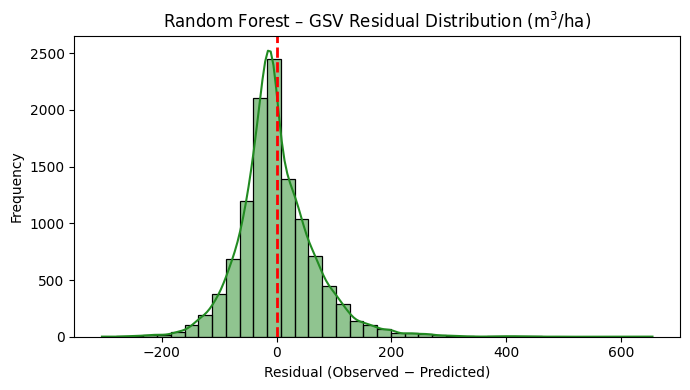

In [98]:
# use residuals from dataframe
residuals_rf = df_results["gsv_residual"]

plt.figure(figsize=(7,4))

sns.histplot(
    residuals_rf,
    bins=40,
    kde=True,
    color="forestgreen",
    edgecolor="black"
)

plt.axvline(0, color="red", linestyle="--", linewidth=2)

plt.title("Random Forest – GSV Residual Distribution (m$^3$/ha)")
plt.xlabel("Residual (Observed − Predicted)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

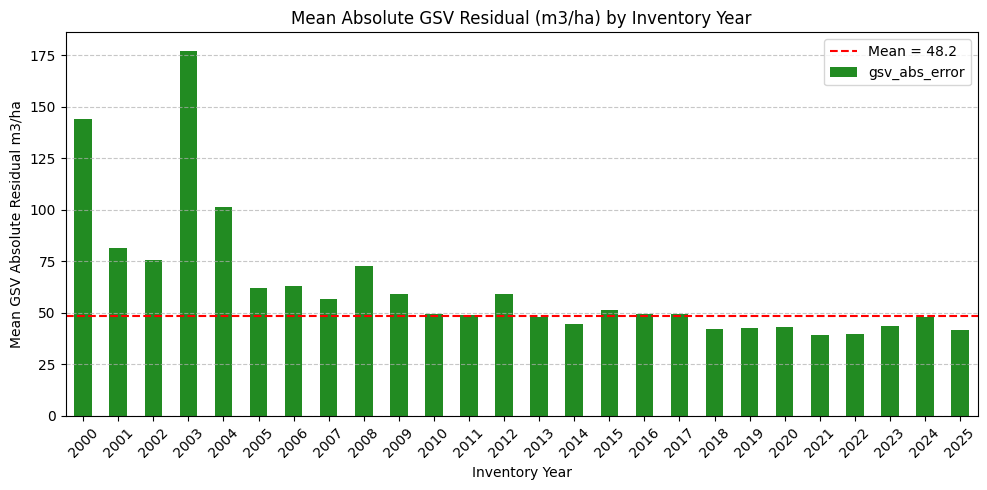

In [99]:
gsv_error_year = df_results.groupby("GTF_NATURE")["gsv_abs_error"].mean()

plt.figure(figsize=(10,5))
gsv_error_year.plot(kind="bar", color="forestgreen")

# correct mean calculation
mean_value_gsv = df_results["gsv_abs_error"].mean()

# add mean line
plt.axhline(mean_value_gsv, linestyle='--', color="red", label=f"Mean = {mean_value_gsv:.1f}")

plt.title("Mean Absolute GSV Residual (m3/ha) by Inventory Year")
plt.xlabel("Inventory Year")
plt.ylabel("Mean GSV Absolute Residual m3/ha")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend()
plt.tight_layout()
plt.show()

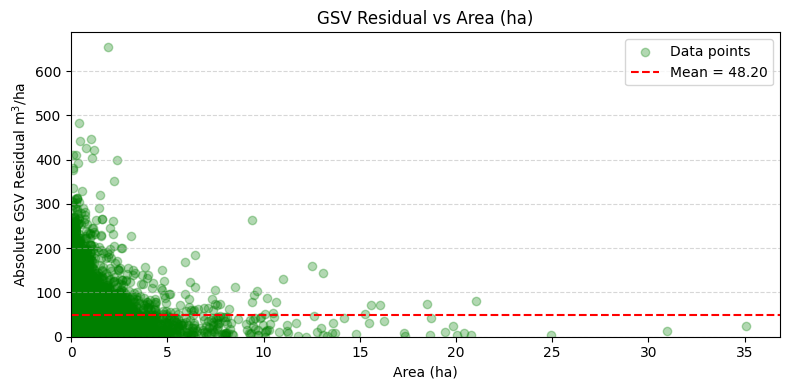

In [100]:
plt.figure(figsize=(8,4))

# scatter
plt.scatter(df_results["PLAT"], df_results["gsv_abs_error"],
            alpha=0.3, color="green", label="Data points")

# calculate mean
mean_error = df_results["gsv_abs_error"].mean()

# add horizontal mean line
plt.axhline(mean_error, color='red', linestyle='--',
            label=f"Mean = {mean_error:.2f}")

plt.title("GSV Residual vs Area (ha)")
plt.xlabel("Area (ha)")
plt.ylabel("Absolute GSV Residual m$^3$/ha")

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# show legend
plt.legend()

plt.tight_layout()
plt.show()

#*Height residual analysis*

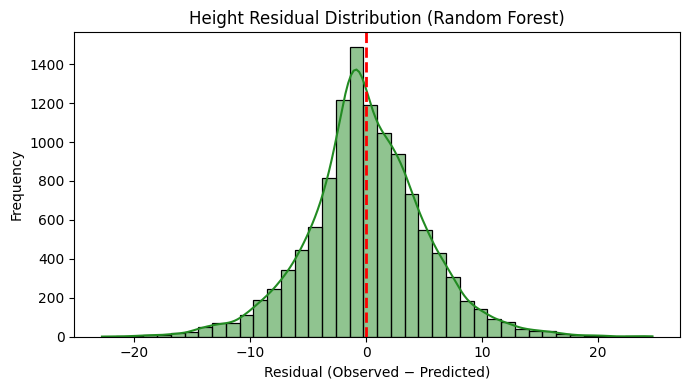

In [101]:
# use residuals from dataframe
residuals_height = df_results["height_residual"]

plt.figure(figsize=(7,4))

sns.histplot(
    residuals_height,
    bins=40,
    kde=True,
    color="forestgreen",
    edgecolor="black"
)

plt.axvline(0, color="red", linestyle="--", linewidth=2)

plt.title("Height Residual Distribution (Random Forest)")
plt.xlabel("Residual (Observed − Predicted)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

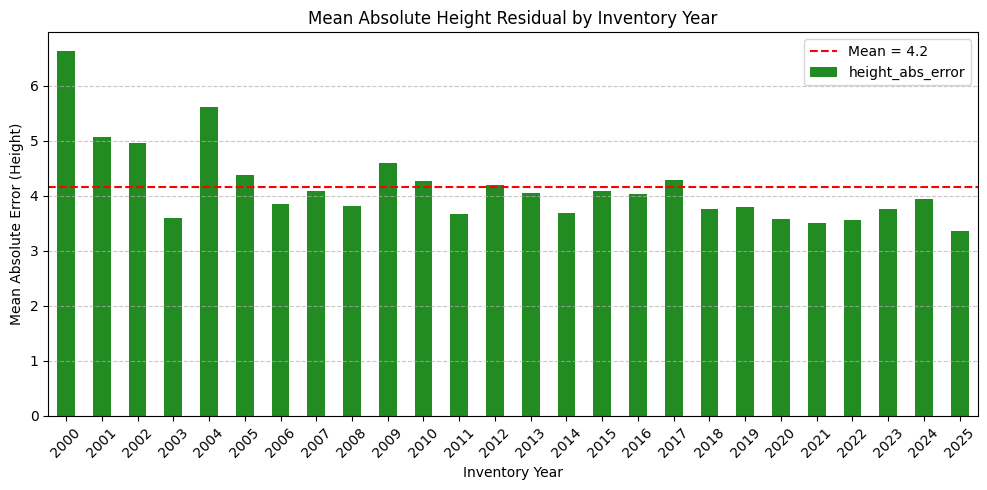

In [102]:
height_error_year = df_results.groupby("GTF_NATURE")["height_abs_error"].mean().sort_index()

# calculate overall mean
mean_value = height_error_year.mean()

plt.figure(figsize=(10,5))
height_error_year.plot(kind="bar", color="forestgreen")

# add mean line WITH label
plt.axhline(mean_value, linestyle='--', color="red", label=f"Mean = {mean_value:.1f}")

plt.title("Mean Absolute Height Residual by Inventory Year")
plt.xlabel("Inventory Year")
plt.ylabel("Mean Absolute Error (Height)")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend()  # now it will show
plt.tight_layout()
plt.show()

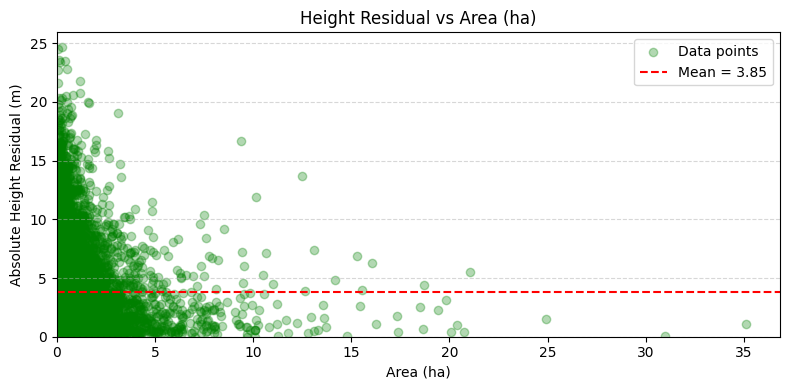

In [103]:
plt.figure(figsize=(8,4))

# scatter
plt.scatter(df_results["PLAT"], df_results["height_abs_error"],
            alpha=0.3, color="green", label="Data points")

# calculate mean
mean_error = df_results["height_abs_error"].mean()

# add horizontal mean line
plt.axhline(mean_error, color='red', linestyle='--',
            label=f"Mean = {mean_error:.2f}")

plt.title("Height Residual vs Area (ha)")
plt.xlabel("Area (ha)")
plt.ylabel("Absolute Height Residual (m)")

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# legend
plt.legend()

plt.tight_layout()
plt.show()

#*Identification of high residual stands*

In [104]:
pd.set_option('display.expand_frame_repr', False)

In [105]:
# filter only Forest type = 10
df_filtered = df_results[df_results["Forest type"] == 10]

# RMSE values
gsv_rmse = 89.552
height_rmse = 6.814

# thresholds (2 × RMSE)
gsv_threshold = 2 * gsv_rmse
height_threshold = 2 * height_rmse

# GSV extreme records
df_gsv_extreme = df_filtered[
    df_filtered["gsv_abs_error"] > gsv_threshold
].sort_values(by="gsv_abs_error", ascending=False)

# Height extreme records
df_height_extreme = df_filtered[
    df_filtered["height_abs_error"] > height_threshold
].sort_values(by="height_abs_error", ascending=False)

# counts
gsv_count = len(df_gsv_extreme)
height_count = len(df_height_extreme)
total = len(df_filtered)


count_10 = (df_results["Forest type"] == 10).sum()

print(f"Forest land: {count_10}")
print(f"GSV (>2×RMSE): {gsv_count} records ({gsv_count/total*100:.2f}%)")
print(f"Height (>2×RMSE): {height_count} records ({height_count/total*100:.2f}%)")



Forest land: 10356
GSV (>2×RMSE): 203 records (1.96%)
Height (>2×RMSE): 147 records (1.42%)


In [106]:
df_combined_extremes = pd.concat([df_filtered[df_filtered["gsv_abs_error"] > gsv_threshold],df_filtered[df_filtered["height_abs_error"] > height_threshold]]).drop_duplicates(subset=["merge_id"])

In [107]:
df_combined_extremes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 277 entries, 8 to 11454
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   merge_id          277 non-null    object 
 1   Forest type       277 non-null    int64  
 2   PLAT              277 non-null    float64
 3   GSV               277 non-null    float64
 4   DOM_SPECIES       277 non-null    int64  
 5   HEIGHT            277 non-null    float64
 6   GTF_NATURE        277 non-null    int64  
 7   age_class         277 non-null    int64  
 8   pred_volume       277 non-null    float64
 9   pred_height       277 non-null    float64
 10  pred_age_class    277 non-null    int64  
 11  pred_species      277 non-null    int64  
 12  gsv_residual      277 non-null    float64
 13  height_residual   277 non-null    float64
 14  gsv_abs_error     277 non-null    float64
 15  height_abs_error  277 non-null    float64
 16  age_error         277 non-null    bool   
 17  

In [108]:
df_combined_extremes.sort_values(by="gsv_abs_error", ascending=False).head(20)
df_combined_extremes.sort_values(by="gsv_abs_error", ascending=False).head(20).to_csv("extreme_stands_gsv.csv", index=False)

In [109]:
df_combined_extremes.sort_values(by="gsv_abs_error", ascending=False).head(20)

,merge_id,Forest type,PLAT,GSV,DOM_SPECIES,HEIGHT,GTF_NATURE,age_class,pred_volume,pred_height,pred_age_class,pred_species,gsv_residual,height_residual,gsv_abs_error,height_abs_error,age_error,species_error
8320,100000000226_1_1_0,10,1.91,887.0,9,11.0,2003,2,232.340488,9.793119,2,9,654.7,1.2,654.7,1.2,False,False
9455,100000000165_5_25_0,10,0.41,673.0,4,27.0,2006,3,189.686608,17.656200,3,4,483.3,9.3,483.3,9.3,False,False
1224,100000000512_1_10_0,10,1.02,597.0,8,26.0,2006,3,150.597322,14.966537,3,4,446.4,11.0,446.4,11.0,False,True
10261,100000000722_1_19_0,10,0.45,520.0,8,29.0,2013,3,78.160382,8.535039,3,4,441.8,20.5,441.8,20.5,False,True
11273,100000000131_11_4_0,10,0.75,656.0,8,25.0,2003,3,229.448111,20.341815,3,4,426.6,4.7,426.6,4.7,False,True
9544,100000000976_2_3_0,10,1.20,505.0,3,29.0,2012,3,83.503603,7.218838,1,3,421.5,21.8,421.5,21.8,True,False
9057,100000000867_6_2_0,10,0.11,426.0,3,2.0,2015,1,14.611038,2.033943,1,3,411.4,-0.0,411.4,0.0,False,False
9115,100000000207_2_1_0,10,0.27,657.0,3,23.0,2006,3,246.371326,15.497343,3,4,410.6,7.5,410.6,7.5,False,True
11264,100000000131_11_3_0,10,1.09,586.0,8,25.0,2003,3,182.032185,17.524516,3,8,404.0,7.5,404.0,7.5,False,False
5705,100000000741_3_1_0,10,2.36,687.0,3,26.0,2008,3,288.812998,21.432492,3,9,398.2,4.6,398.2,4.6,False,True


In [110]:
df_results.sort_values(by="pred_volume", ascending=False).head(10)

,merge_id,Forest type,PLAT,GSV,DOM_SPECIES,HEIGHT,GTF_NATURE,age_class,pred_volume,pred_height,pred_age_class,pred_species,gsv_residual,height_residual,gsv_abs_error,height_abs_error,age_error,species_error
9500,100000000165_5_4_0,10,1.55,632.0,1,29.0,2006,3,403.642531,25.989256,3,1,228.4,3.0,228.4,3.0,False,False
44,100000000559_1_14_0,10,0.33,439.0,1,29.0,2012,4,398.443863,24.970039,3,1,40.6,4.0,40.6,4.0,True,False
3480,100000000456_1_24_0,10,0.24,521.0,3,25.0,2023,3,390.163616,19.920986,3,3,130.8,5.1,130.8,5.1,False,False
606,100000000553_1_20_0,10,0.24,488.0,4,28.0,2011,3,389.065953,25.202055,3,4,98.9,2.8,98.9,2.8,False,False
482,100000000031_1_5_0,10,0.81,422.0,4,26.0,2008,3,387.463454,24.586181,3,4,34.5,1.4,34.5,1.4,False,False
4018,100000000529_1_22_0,10,0.96,425.0,1,27.0,2024,3,387.252688,25.076311,3,1,37.7,1.9,37.7,1.9,False,False
3489,100000000456_1_33_0,10,0.85,464.0,3,24.0,2023,3,384.065785,22.289619,3,3,79.9,1.7,79.9,1.7,False,False
5064,100000000950_1_16_0,10,1.32,436.0,1,25.0,2014,3,379.393060,23.485475,4,1,56.6,1.5,56.6,1.5,True,False
9501,100000000165_5_5_0,10,1.12,437.0,3,19.0,2006,3,379.173718,22.558492,3,1,57.8,-3.6,57.8,3.6,False,True
7760,100000000979_1_3_0,10,0.93,399.0,1,26.0,2022,3,377.165089,22.682677,3,1,21.8,3.3,21.8,3.3,False,False


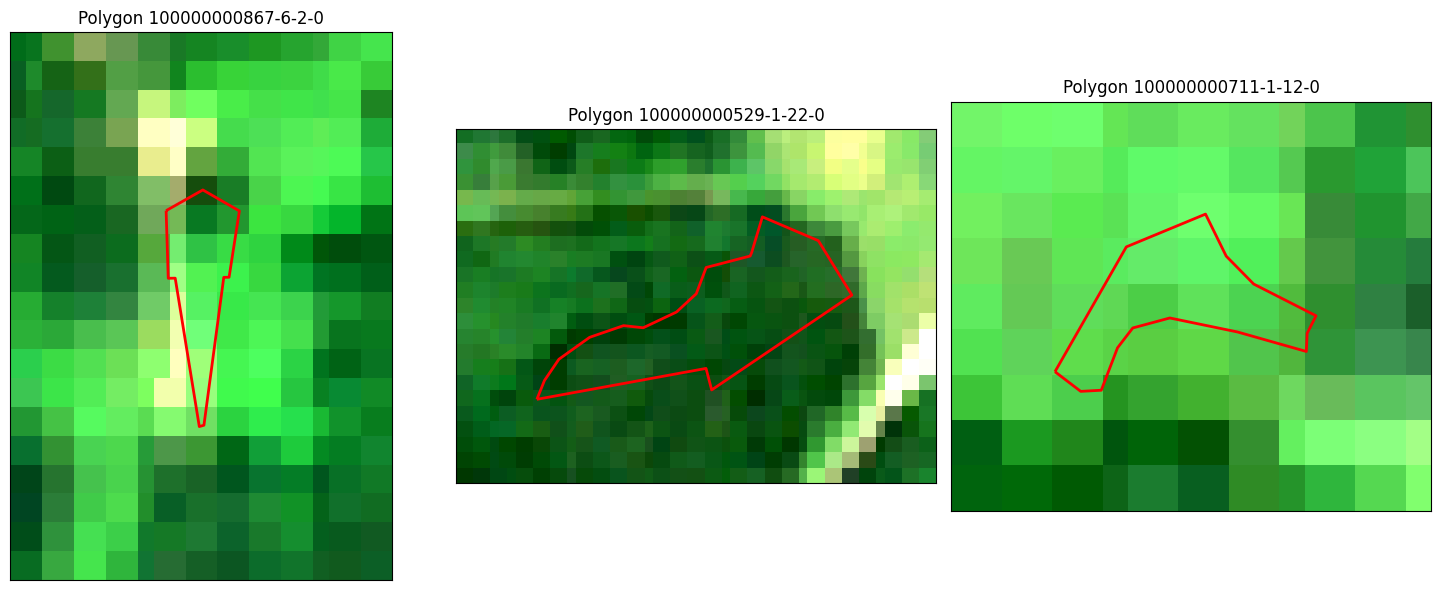

In [111]:
# load polygons once
forest = gpd.read_file("Nogapoly.shp")

# function to load + plot
def plot_polygon(ax, tif_path, kadnum, kvartals, nogabals, apaksnog, title):

    # open raster
    with rasterio.open(tif_path) as src:
        img = src.read()
        bounds = src.bounds
        crs = src.crs

    # convert to RGB
    rgb = img.transpose(1, 2, 0)

    # stretch (important)
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)

    # reproject polygons
    forest_proj = forest.to_crs(crs)

    # select polygon
    poly = forest_proj[
        (forest_proj["KADNUM"] == kadnum) &
        (forest_proj["KVARTALS"] == kvartals) &
        (forest_proj["NOGABALS"] == nogabals) &
        (forest_proj["APAKSNOG"] == apaksnog)
    ]

    # plot image
    ax.imshow(
        rgb,
        extent=[bounds.left, bounds.right,
                bounds.bottom, bounds.top]
    )

    # plot polygon
    poly.boundary.plot(ax=ax, edgecolor="red", linewidth=2)

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


# ---- create figure ----
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# LEFT plot
plot_polygon(
    axes[0],
    "nice_satellite_image100000000867.tif",
    "100000000867", 6, 2, 0,
    "Polygon 100000000867-6-2-0"
)

# MIDDLE plot
plot_polygon(
    axes[1],
    "nice_satellite_image100000000529.tif",
    "100000000529", 1, 22, 0,
    "Polygon 100000000529-1-22-0"
)

# RIGHT plot (NEW)
plot_polygon(
    axes[2],
    "nice_satellite_image100000000711.tif",
    "100000000711", 1, 12, 0,
    "Polygon 100000000711-1-12-0"
)


plt.tight_layout()
plt.show()



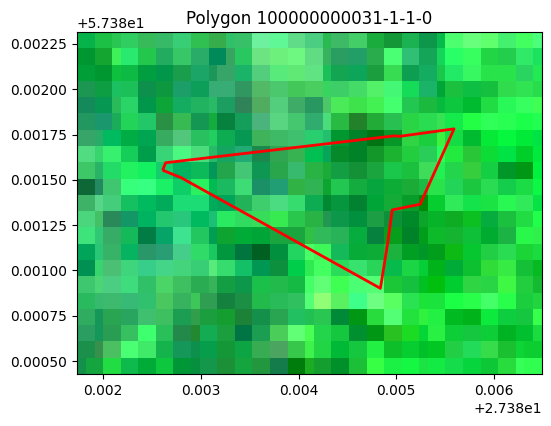

In [112]:
# open raster
with rasterio.open("nice_satellite_image100000000031.tif") as src:
    img = src.read()
    bounds = src.bounds
    crs = src.crs

# convert to RGB
rgb = img.transpose(1,2,0)
p2, p98 = np.percentile(rgb, (2,98))
rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)

# load polygons
forest = gpd.read_file("Nogapoly.shp").to_crs(crs)

poly = forest[
    (forest["KADNUM"] == "100000000031") &
    (forest["KVARTALS"] == 1) &
    (forest["NOGABALS"] == 5) &
    (forest["APAKSNOG"] == 0)
]

fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(rgb,extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])

poly.boundary.plot(ax=ax, edgecolor="red", linewidth=2)

plt.title("Polygon 100000000031-1-1-0")
plt.show()

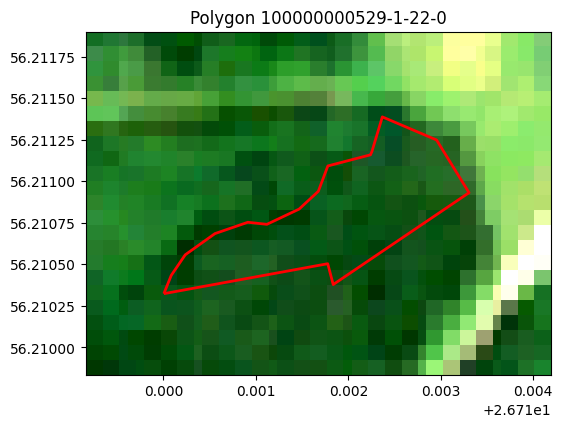

In [113]:
# open raster
with rasterio.open("nice_satellite_image100000000529.tif") as src:
    img = src.read()
    bounds = src.bounds
    crs = src.crs

# convert to RGB
rgb = img.transpose(1,2,0)
p2, p98 = np.percentile(rgb, (2,98))
rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)

# load polygons
forest = gpd.read_file("Nogapoly.shp").to_crs(crs)

poly = forest[
    (forest["KADNUM"] == "100000000529") &
    (forest["KVARTALS"] == 1) &
    (forest["NOGABALS"] == 22) &
    (forest["APAKSNOG"] == 0)
]

fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(rgb,extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])

poly.boundary.plot(ax=ax, edgecolor="red", linewidth=2)

plt.title("Polygon 100000000529-1-22-0")
plt.show()

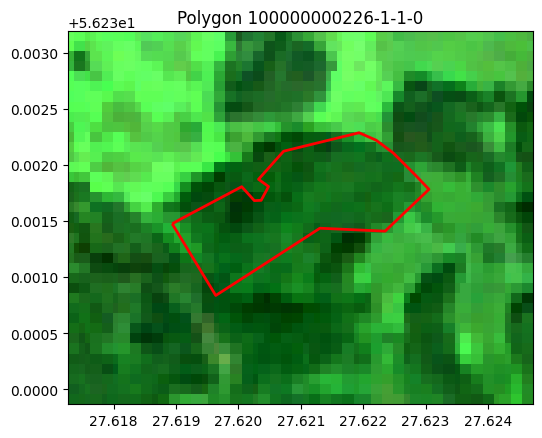

In [114]:
# open raster
with rasterio.open("nice_satellite_image100000000226.tif") as src:
    img = src.read()
    bounds = src.bounds
    crs = src.crs

# convert to RGB
rgb = img.transpose(1,2,0)
p2, p98 = np.percentile(rgb, (2,98))
rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)

# load polygons
forest = gpd.read_file("Nogapoly.shp").to_crs(crs)

poly = forest[
    (forest["KADNUM"] == "100000000226") &
    (forest["KVARTALS"] == 1) &
    (forest["NOGABALS"] == 1) &
    (forest["APAKSNOG"] == 0)
]

fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(rgb,extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])

poly.boundary.plot(ax=ax, edgecolor="red", linewidth=2)

plt.title("Polygon 100000000226-1-1-0")
plt.show()

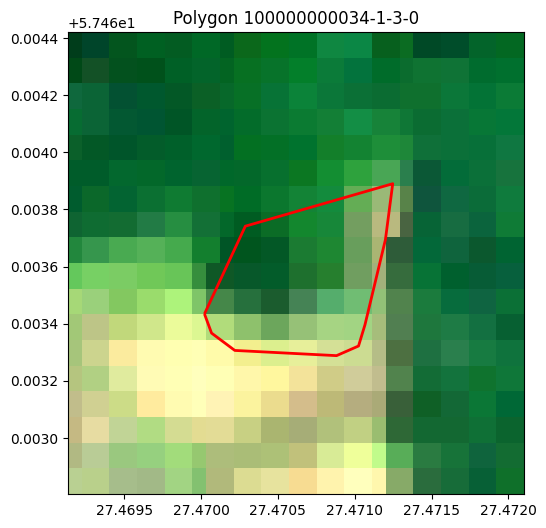

In [115]:
# open raster
with rasterio.open("nice_satellite_image100000000034.tif") as src:
    img = src.read()
    bounds = src.bounds
    crs = src.crs

# convert to RGB
rgb = img.transpose(1,2,0)
p2, p98 = np.percentile(rgb, (2,98))
rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)

# load polygons
forest = gpd.read_file("Nogapoly.shp").to_crs(crs)

poly = forest[
    (forest["KADNUM"] == "100000000034") &
    (forest["KVARTALS"] == 1) &
    (forest["NOGABALS"] == 3) &
    (forest["APAKSNOG"] == 0)
]

fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(rgb,extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])

poly.boundary.plot(ax=ax, edgecolor="red", linewidth=2)

plt.title("Polygon 100000000034-1-3-0")
plt.show()

9
            KADNUM  KVARTALS  NOGABALS  APAKSNOG
1342  100000000034         1         3         0
1343  100000000034         1         1         0
1344  100000000034         1         6         0
1345  100000000034         1         7         0
1346  100000000034         1         5         0
1347  100000000034         1         4         0
1348  100000000034         1         8         0
1349  100000000034         1         9         0
1350  100000000034         1         2         0


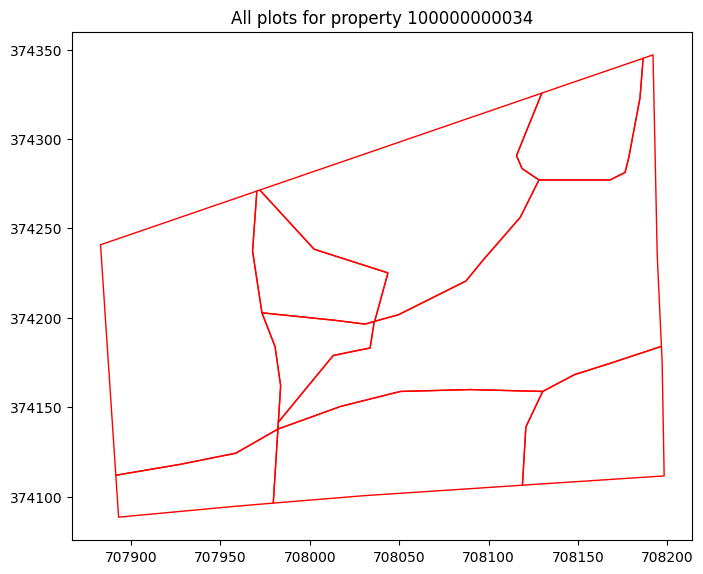

In [116]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("Nogapoly.shp")

gdf["KADNUM_str"] = (
    gdf["KADNUM"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)

prop_plots = gdf[gdf["KADNUM_str"] == "100000000034"]

print(prop_plots.shape[0])
print(prop_plots[["KADNUM", "KVARTALS", "NOGABALS", "APAKSNOG"]])

if not prop_plots.empty:
    fig, ax = plt.subplots(figsize=(8, 8))
    prop_plots.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=1)
    ax.set_title("All plots for property 100000000034")
    plt.show()
else:
    print("No matching plots found.")

#*Age class and Dominant species error analysis*

In [117]:
df_results.head(5)

,merge_id,Forest type,PLAT,GSV,DOM_SPECIES,HEIGHT,GTF_NATURE,age_class,pred_volume,pred_height,pred_age_class,pred_species,gsv_residual,height_residual,gsv_abs_error,height_abs_error,age_error,species_error
0,100000000113_1_10_0,10,0.03,305.0,4,26.0,2006,3,265.205377,19.049641,3,4,39.8,7.0,39.8,7.0,False,False
1,100000000113_1_3_0,10,0.08,179.0,9,20.0,2006,2,139.101407,16.294971,2,4,39.9,3.7,39.9,3.7,False,True
2,100000000113_1_8_0,10,0.05,289.0,4,28.0,2006,3,202.502586,21.471082,3,4,86.5,6.5,86.5,6.5,False,False
3,100000000098_2_2_0,10,1.94,64.0,3,7.0,2001,1,172.508281,15.645935,1,3,-108.5,-8.6,108.5,8.6,False,False
4,100000000192_2_1_0,10,0.69,279.0,1,24.0,2006,4,240.474012,20.052267,4,1,38.5,3.9,38.5,3.9,False,False


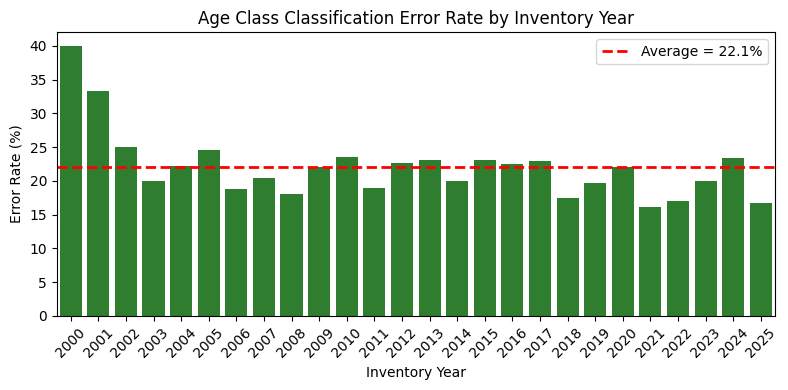

In [118]:
age_year_rate = (
    df_results.groupby("GTF_NATURE")["age_error"]
    .mean()
    .reset_index()
    .sort_values("GTF_NATURE")
)
age_year_rate["age_error"] *= 100

avg_error = age_year_rate["age_error"].mean()

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=age_year_rate, x="GTF_NATURE", y="age_error", color="forestgreen", ax=ax)

ax.axhline(avg_error, color="red", linestyle="--", linewidth=2,
           label=f"Average = {avg_error:.1f}%")

ax.set_title("Age Class Classification Error Rate by Inventory Year")
ax.set_xlabel("Inventory Year")
ax.set_ylabel("Error Rate (%)")
plt.xticks(rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

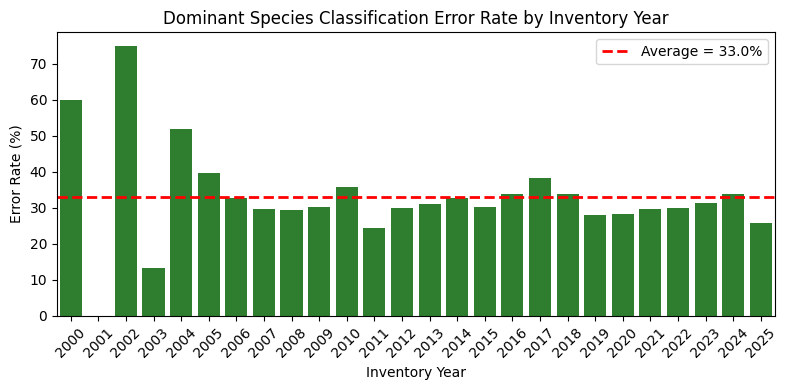

In [119]:
species_year_rate = (
    df_results.groupby("GTF_NATURE")["species_error"]
    .mean()
    .reset_index()
    .sort_values("GTF_NATURE")
)
species_year_rate["species_error"] *= 100

avg_error = species_year_rate["species_error"].mean()

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=species_year_rate, x="GTF_NATURE", y="species_error", color="forestgreen", ax=ax)

ax.axhline(avg_error, color="red", linestyle="--", linewidth=2,
           label=f"Average = {avg_error:.1f}%")

ax.set_title("Dominant Species Classification Error Rate by Inventory Year")
ax.set_xlabel("Inventory Year")
ax.set_ylabel("Error Rate (%)")
plt.xticks(rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

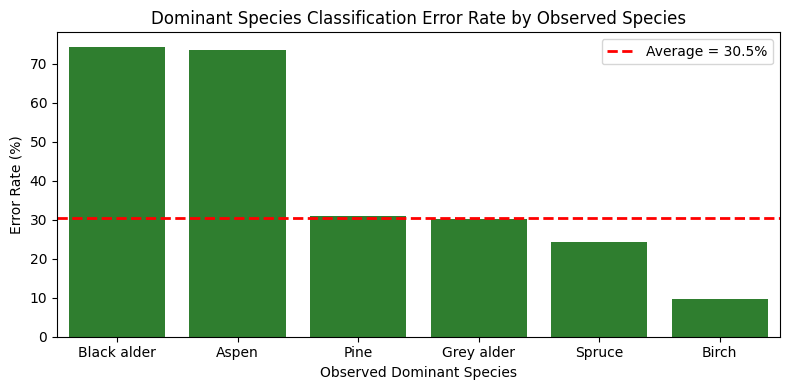

In [120]:
# map names
df_results["DOM_SPECIES_NAME"] = df_results["DOM_SPECIES"].map(species_names)
df_results["PRED_SPECIES_NAME"] = df_results["pred_species"].map(species_names)

# top 6 observed species
top6 = df_results["DOM_SPECIES_NAME"].value_counts().head(6).index.tolist()

# error rate for top 6 observed species
species_error_rate = (
    df_results[df_results["DOM_SPECIES_NAME"].isin(top6)]
    .groupby("DOM_SPECIES_NAME")["species_error"]
    .mean()
    .reset_index()
)

species_error_rate["species_error"] *= 100
species_error_rate = species_error_rate.sort_values("species_error", ascending=False)

# overall average species classification error rate
avg_error = df_results["species_error"].mean() * 100

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(
    data=species_error_rate,
    x="DOM_SPECIES_NAME",
    y="species_error",
    color="forestgreen",
    ax=ax
)

ax.axhline(
    avg_error,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Average = {avg_error:.1f}%"
)

ax.set_title("Dominant Species Classification Error Rate by Observed Species")
ax.set_xlabel("Observed Dominant Species")
ax.set_ylabel("Error Rate (%)")
plt.xticks(rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

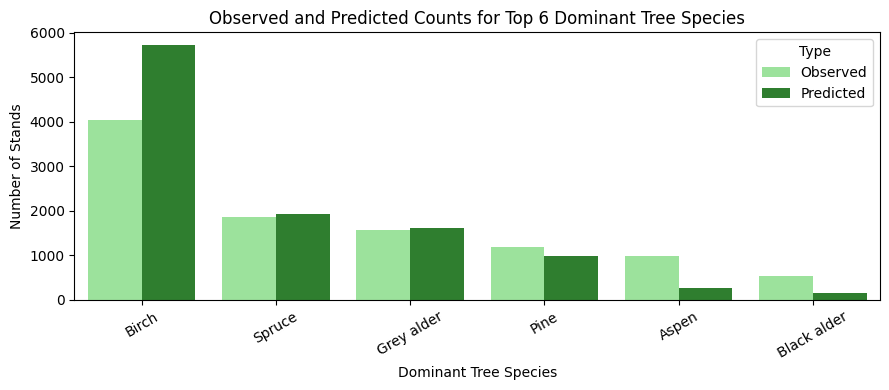

In [127]:
# observed counts
obs_counts = df_results["DOM_SPECIES_NAME"].value_counts()

# predicted counts
pred_counts = df_results["PRED_SPECIES_NAME"].value_counts()

# top 6 from observed
top6 = obs_counts.head(6).index.tolist()

compare_counts = pd.DataFrame({
    "Observed": obs_counts.reindex(top6, fill_value=0),
    "Predicted": pred_counts.reindex(top6, fill_value=0)
}).reset_index().rename(columns={"index": "Species"})

compare_long = compare_counts.melt(id_vars="Species",
                                   value_vars=["Observed", "Predicted"],
                                   var_name="Type",
                                   value_name="Count")

fig, ax = plt.subplots(figsize=(9,4))
sns.barplot(data=compare_long,x="Species",y="Count",hue="Type",palette={"Observed": "lightgreen", "Predicted": "forestgreen"}, ax=ax)
ax.set_title("Observed and Predicted Counts for Top 6 Dominant Tree Species")
ax.set_xlabel("Dominant Tree Species")
ax.set_ylabel("Number of Stands")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

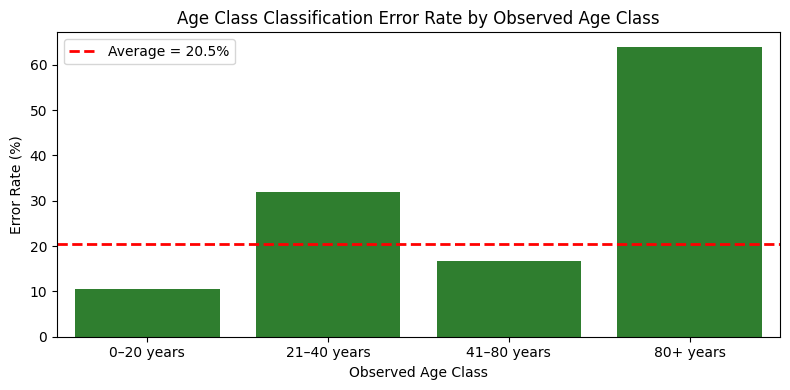

In [128]:
# map age class names
age_class_names = {
    1: "0–20 years",
    2: "21–40 years",
    3: "41–80 years",
    4: "80+ years"
}

df_results["AGE_CLASS_NAME"] = df_results["age_class"].map(age_class_names)
df_results["PRED_AGE_CLASS_NAME"] = df_results["pred_age_class"].map(age_class_names)

# error rate by observed age class
age_error_rate = (
    df_results.groupby("AGE_CLASS_NAME")["age_error"]
    .mean()
    .reset_index()
)

age_error_rate["age_error"] *= 100

# keep logical order
age_order = ["0–20 years", "21–40 years", "41–80 years", "80+ years"]
age_error_rate["AGE_CLASS_NAME"] = pd.Categorical(
    age_error_rate["AGE_CLASS_NAME"],
    categories=age_order,
    ordered=True
)
age_error_rate = age_error_rate.sort_values("AGE_CLASS_NAME")

# overall average error rate
avg_error = df_results["age_error"].mean() * 100

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(
    data=age_error_rate,
    x="AGE_CLASS_NAME",
    y="age_error",
    color="forestgreen",
    ax=ax
)

ax.axhline(
    avg_error,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Average = {avg_error:.1f}%"
)

ax.set_title("Age Class Classification Error Rate by Observed Age Class")
ax.set_xlabel("Observed Age Class")
ax.set_ylabel("Error Rate (%)")
plt.xticks(rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_11105/1759384091.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_results.groupby("GSV_bin")["species_error"]


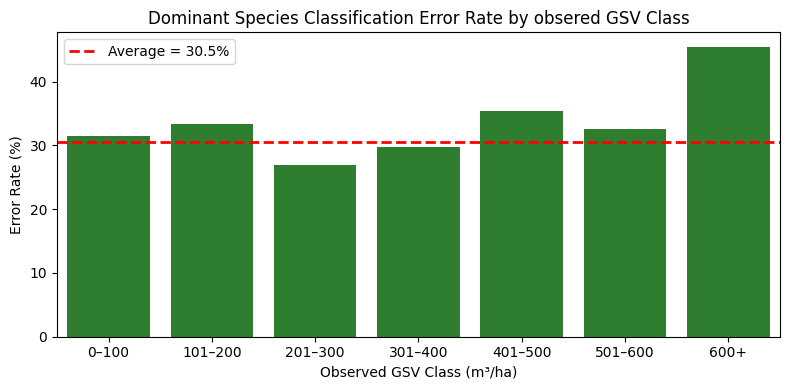

In [129]:
# create GSV bins
gsv_bins = [0, 50, 100, 200, 300, 400, 600, 1000]
gsv_labels = ["0–100", "101–200", "201–300", "301–400", "401–500", "501–600", "600+"]

df_results["GSV_bin"] = pd.cut(
    df_results["GSV"],
    bins=gsv_bins,
    labels=gsv_labels,
    include_lowest=True
)

# species classification error rate by GSV bin
species_gsv_error = (
    df_results.groupby("GSV_bin")["species_error"]
    .mean()
    .reset_index()
)

species_gsv_error["species_error"] *= 100

avg_error = df_results["species_error"].mean() * 100

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=species_gsv_error, x="GSV_bin", y="species_error",
            color="forestgreen", ax=ax)

ax.axhline(avg_error, color="red", linestyle="--", linewidth=2,
           label=f"Average = {avg_error:.1f}%")

ax.set_title("Dominant Species Classification Error Rate by obsered GSV Class")
ax.set_xlabel("Observed GSV Class (m³/ha)")
ax.set_ylabel("Error Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_11105/4023747314.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_results.groupby("GSV_bin")["age_error"]


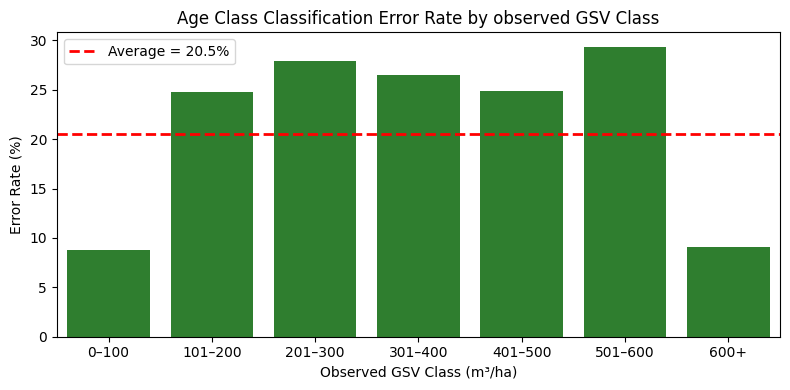

In [130]:
age_gsv_error = (
    df_results.groupby("GSV_bin")["age_error"]
    .mean()
    .reset_index()
)

age_gsv_error["age_error"] *= 100

avg_error = df_results["age_error"].mean() * 100

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=age_gsv_error, x="GSV_bin", y="age_error",
            color="forestgreen", ax=ax)

ax.axhline(avg_error, color="red", linestyle="--", linewidth=2,
           label=f"Average = {avg_error:.1f}%")

ax.set_title("Age Class Classification Error Rate by observed GSV Class")
ax.set_xlabel("Observed GSV Class (m³/ha)")
ax.set_ylabel("Error Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_11105/1900585718.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_results.groupby("PLAT_bin")["species_error"]


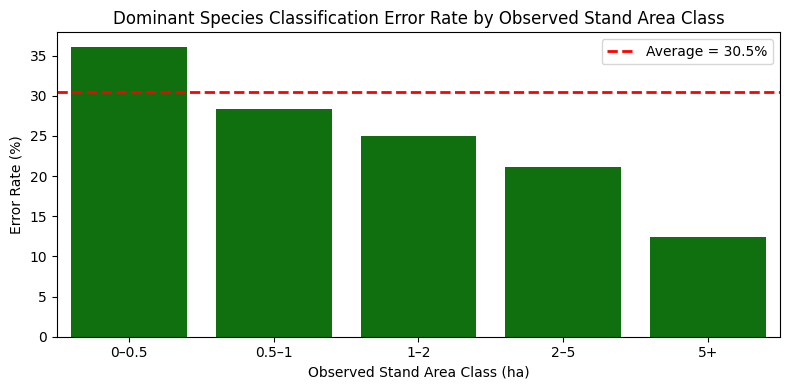

In [131]:
# create PLAT bins
plat_bins = [0, 0.5, 1, 2, 5, df_results["PLAT"].max()]
plat_labels = ["0–0.5", "0.5–1", "1–2", "2–5", "5+"]

df_results["PLAT_bin"] = pd.cut(
    df_results["PLAT"],
    bins=plat_bins,
    labels=plat_labels,
    include_lowest=True
)

species_plat_error = (
    df_results.groupby("PLAT_bin")["species_error"]
    .mean()
    .reset_index()
)

species_plat_error["species_error"] *= 100
avg_error = df_results["species_error"].mean() * 100

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=species_plat_error, x="PLAT_bin", y="species_error",
            color="green", ax=ax)

ax.axhline(avg_error, color="red", linestyle="--", linewidth=2,
           label=f"Average = {avg_error:.1f}%")

ax.set_title("Dominant Species Classification Error Rate by Observed Stand Area Class")
ax.set_xlabel("Observed Stand Area Class (ha)")
ax.set_ylabel("Error Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_11105/3976574275.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_results.groupby("PLAT_bin")["age_error"]


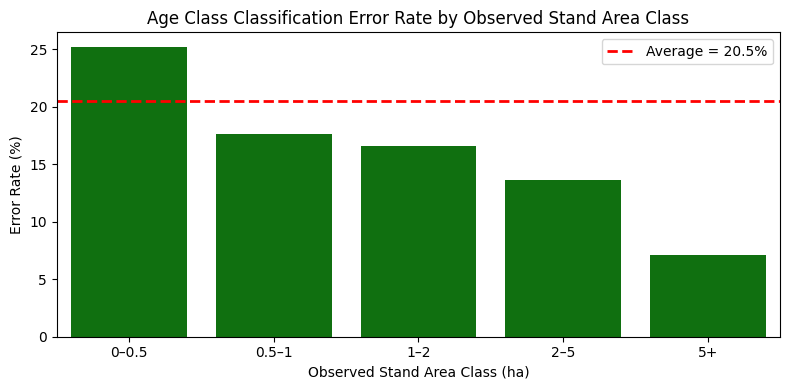

In [133]:
age_plat_error = (
    df_results.groupby("PLAT_bin")["age_error"]
    .mean()
    .reset_index()
)

age_plat_error["age_error"] *= 100
avg_error = df_results["age_error"].mean() * 100

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=age_plat_error, x="PLAT_bin", y="age_error",
            color="green", ax=ax)

ax.axhline(avg_error, color="red", linestyle="--", linewidth=2,
           label=f"Average = {avg_error:.1f}%")

ax.set_title("Age Class Classification Error Rate by Observed Stand Area Class")
ax.set_xlabel("Observed Stand Area Class (ha)")
ax.set_ylabel("Error Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()